In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 3.8)
plt.rcParams["axes.titleweight"] = "bold"

NAVY, GOLD, GRAY, RED = "#16273E", "#F4AC02", "#D2D3D5", "#C0392B"
rng = np.random.default_rng(42)

# ---------- Dados de exemplo (sintéticos) usados em todo o notebook ----------
produtos = ["Notebook", "Celular", "Tablet", "Monitor", "Teclado", "Mouse", "Webcam", "Headset"]
vendas_prod = pd.Series([320, 540, 210, 180, 95, 130, 70, 160], index=produtos, name="vendas")
var_pct = pd.Series([12, 8, 5, -3, -7, -11, 4, -2], index=produtos, name="var_pct")

meses = pd.date_range("2023-01-01", periods=24, freq="MS")
t = np.arange(24)
serie = pd.DataFrame({"mes": meses,
                      "receita": 100 + 3 * t + 12 * np.sin(2 * np.pi * t / 12) + rng.normal(0, 4, 24)})
serie["custo"] = serie["receita"] * 0.7 + rng.normal(0, 3, 24)

n = 250
df = pd.DataFrame({"grupo": rng.choice(["A", "B", "C"], n)})
df["x"] = rng.normal(50, 10, n) + df["grupo"].map({"A": 0, "B": 8, "C": 16})
df["y"] = 0.8 * df["x"] + rng.normal(0, 6, n)
df["z"] = -0.5 * df["x"] + rng.normal(0, 8, n)
df["tamanho"] = rng.uniform(10, 100, n)

cidades = pd.DataFrame({
    "nome": ["São Paulo", "Rio de Janeiro", "Brasília", "Salvador", "Fortaleza",
             "Manaus", "Porto Alegre", "Belo Horizonte", "Recife", "Curitiba"],
    "lon": [-46.6, -43.2, -47.9, -38.5, -38.5, -60.0, -51.2, -43.9, -34.9, -49.3],
    "lat": [-23.5, -22.9, -15.8, -13.0, -3.7, -3.1, -30.0, -19.9, -8.1, -25.4],
    "pop": [12.3, 6.7, 3.1, 2.4, 2.7, 2.2, 1.3, 2.3, 1.6, 1.8]})


<img src="https://keystoneacademic-res.cloudinary.com/image/upload/c_pad,w_640,h_304/dpr_auto/f_auto/q_auto/v1/element/94/94774_thumb.png" width=300>

# Programação para Análise de Dados

## Aula 11: Visual Vocabulary — o significado de cada gráfico

### Baseado no *Visual Vocabulary* do Financial Times

#### Matplotlib e Seaborn: exemplos básicos e snippets de código

**Como escolher um gráfico?** Em vez de começar pelo tipo de gráfico, comece pela **mensagem** que você quer passar.

O *Visual Vocabulary* organiza os gráficos em 9 categorias, cada uma respondendo a uma pergunta:

| Categoria | Pergunta que responde |
|---|---|
| **Deviation** (Desvio) | O que está acima ou abaixo de uma referência? |
| **Correlation** (Correlação) | As variáveis se relacionam? |
| **Ranking** | Quem está na frente e quem está atrás? |
| **Distribution** (Distribuição) | Como os valores se espalham? |
| **Change over Time** (Evolução no tempo) | Como isso mudou ao longo do tempo? |
| **Magnitude** | Qual é o tamanho de cada coisa? |
| **Part-to-whole** (Partes de um todo) | Como o total se divide? |
| **Spatial** (Espacial) | Onde isso acontece? |
| **Flow** (Fluxo) | De onde para onde as coisas se movem? |

⚠️ **Sobre os dados:** todos os exemplos usam dados **sintéticos** criados na primeira célula (oculta no modo slide): `vendas_prod`, `var_pct`, `serie`, `df` e `cidades`. Rode essa célula antes das demais.

⚠️ **Sobre os mapas:** como não usamos arquivos geográficos, os exemplos da categoria *Spatial* são esquemáticos. Em projetos reais use `geopandas`, `plotly` ou `folium`.

# Parte 1 — Os gráficos mais usados

Barras, histogramas, pizza, linhas, dispersão (scatter) e mapas de calor (heatmaps). Cada um com a versão **matplotlib** e/ou **seaborn**.

### Gráfico de barras / colunas · *Bar / Column chart*

**Mensagem:** Compara a magnitude de categorias distintas: qual é maior, qual é menor e por quanto.

**Quando usar:** Poucas a dezenas de categorias com um valor numérico cada (vendas por produto, população por país).

⚠️ **Cuidado:** A base deve começar em zero: truncar o eixo exagera diferenças. Ordene as barras quando a posição importar.

*Biblioteca no exemplo: matplotlib + seaborn*

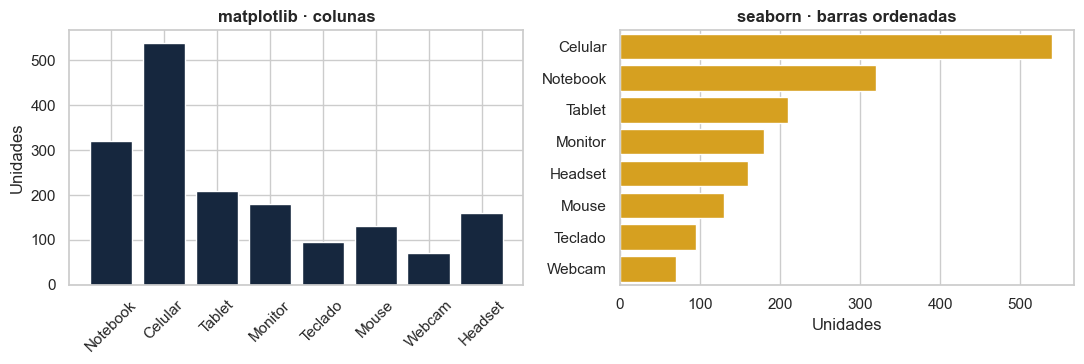

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# matplotlib: colunas (barras verticais)
axes[0].bar(vendas_prod.index, vendas_prod.values, color=NAVY)
axes[0].set(title="matplotlib · colunas", ylabel="Unidades")
axes[0].tick_params(axis="x", rotation=45)

# seaborn: barras horizontais ordenadas
ordem = vendas_prod.sort_values(ascending=False)
sns.barplot(x=ordem.values, y=ordem.index, orient="h", color=GOLD, ax=axes[1])
axes[1].set(title="seaborn · barras ordenadas", xlabel="Unidades", ylabel="")
plt.tight_layout(); plt.show()

### Histograma · *Histogram*

**Mensagem:** Mostra a distribuição de uma variável numérica: onde os valores se concentram, simetria e caudas.

**Quando usar:** Uma variável contínua com muitas observações (idades, salários, tempos de resposta).

⚠️ **Cuidado:** O número de bins altera a história contada: teste vários. Não confunda com gráfico de barras.

*Biblioteca no exemplo: matplotlib + seaborn*

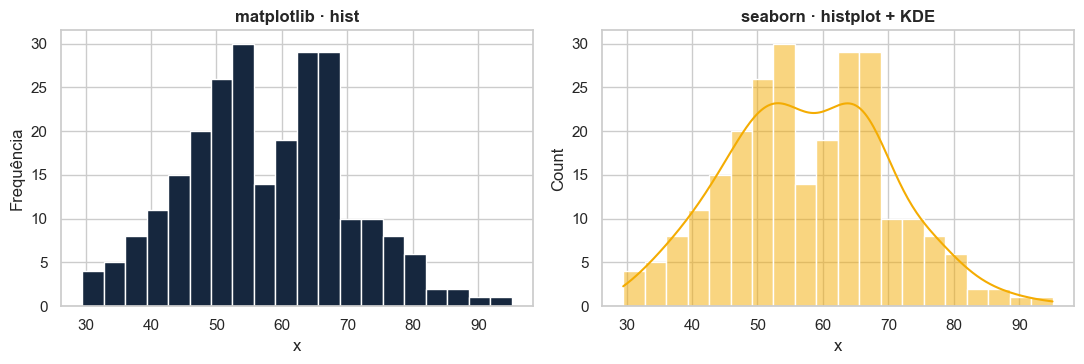

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df["x"], bins=20, color=NAVY, edgecolor="white")
axes[0].set(title="matplotlib · hist", xlabel="x", ylabel="Frequência")

sns.histplot(data=df, x="x", bins=20, kde=True, color=GOLD, ax=axes[1])
axes[1].set(title="seaborn · histplot + KDE", xlabel="x")
plt.tight_layout(); plt.show()

### Gráfico de pizza · *Pie chart*

**Mensagem:** Mostra a participação de cada parte no total (100%).

**Quando usar:** Até ~5 fatias, quando a soma é um todo significativo e as diferenças entre partes são grandes.

⚠️ **Cuidado:** Humanos comparam ângulos mal. Evite muitas fatias ou valores parecidos; prefira barras ordenadas.

*Biblioteca no exemplo: matplotlib*

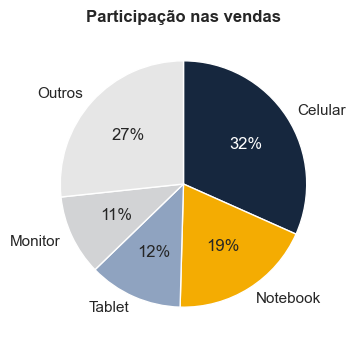

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
top = vendas_prod.sort_values(ascending=False)
outros = top.iloc[4:].sum()
partes = pd.concat([top.iloc[:4], pd.Series({"Outros": outros})])

_, _, pct = ax.pie(partes, labels=partes.index, autopct="%1.0f%%", startangle=90, counterclock=False,
                   colors=[NAVY, GOLD, "#8FA3C0", GRAY, "#E6E6E6"], wedgeprops=dict(edgecolor="white"))
pct[0].set_color("white")  # texto claro sobre a fatia escura
ax.set_title("Participação nas vendas")
plt.show()

### Gráfico de linhas · *Line chart*

**Mensagem:** Mostra a evolução de uma variável ao longo do tempo: tendência, sazonalidade e rupturas.

**Quando usar:** Séries temporais contínuas, com pontos igualmente espaçados.

⚠️ **Cuidado:** Use datas reais no eixo x. Várias linhas demais viram "espaguete": destaque a que importa.

*Biblioteca no exemplo: matplotlib + seaborn*

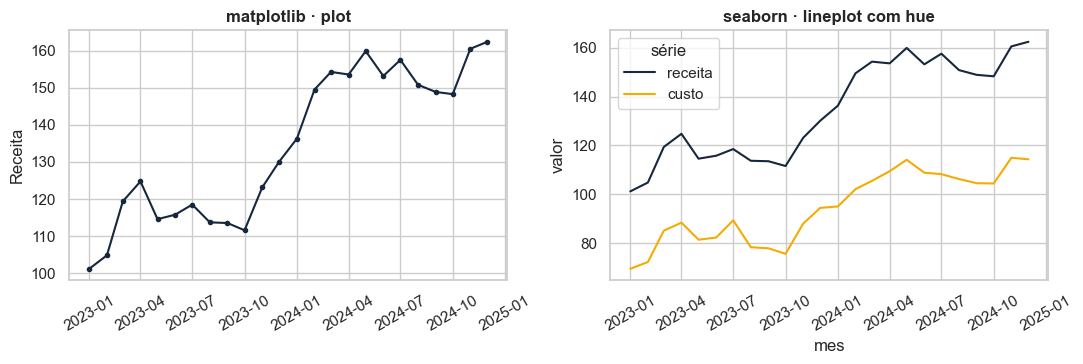

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(serie["mes"], serie["receita"], color=NAVY, marker="o", ms=3)
axes[0].set(title="matplotlib · plot", ylabel="Receita")
axes[0].tick_params(axis="x", rotation=30)

longo = serie.melt("mes", value_vars=["receita", "custo"], var_name="série", value_name="valor")
sns.lineplot(data=longo, x="mes", y="valor", hue="série", palette=[NAVY, GOLD], ax=axes[1])
axes[1].set(title="seaborn · lineplot com hue")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### Gráfico de dispersão (scatter) · *Scatterplot*

**Mensagem:** Mostra a relação entre duas variáveis numéricas: direção, força, formato e outliers.

**Quando usar:** Duas variáveis contínuas medidas nas mesmas observações.

⚠️ **Cuidado:** Correlação não é causalidade. Com muitos pontos use transparência (`alpha`) para evitar sobreposição.

*Biblioteca no exemplo: matplotlib + seaborn*

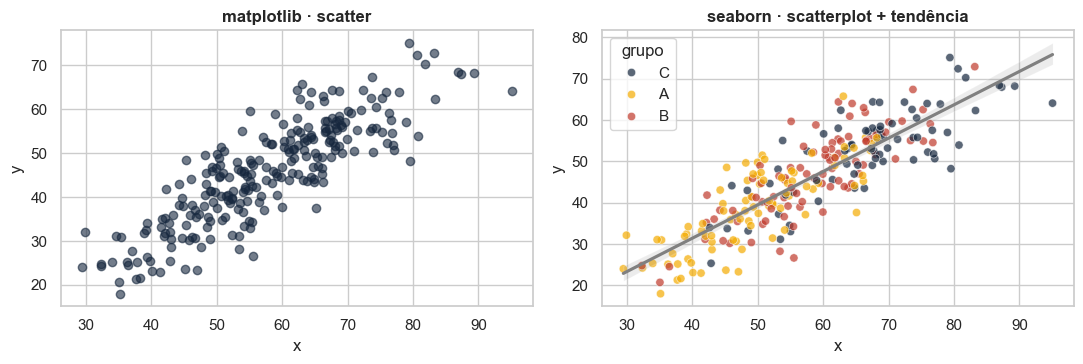

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].scatter(df["x"], df["y"], alpha=0.6, color=NAVY)
axes[0].set(title="matplotlib · scatter", xlabel="x", ylabel="y")

sns.scatterplot(data=df, x="x", y="y", hue="grupo", palette=[NAVY, GOLD, RED], alpha=0.7, ax=axes[1])
sns.regplot(data=df, x="x", y="y", scatter=False, color="gray", ax=axes[1])
axes[1].set(title="seaborn · scatterplot + tendência")
plt.tight_layout(); plt.show()

### Mapa de calor (heatmap) · *Heatmap*

**Mensagem:** Mostra a intensidade de valores numa matriz por meio de cor: padrões, blocos e contrastes.

**Quando usar:** Matrizes de correlação, tabelas cruzadas (dia × hora), comparações de muitas linhas × colunas.

⚠️ **Cuidado:** Escolha paleta sequencial para valores e divergente (centrada em 0) para correlações. Anote os valores quando possível.

*Biblioteca no exemplo: seaborn*

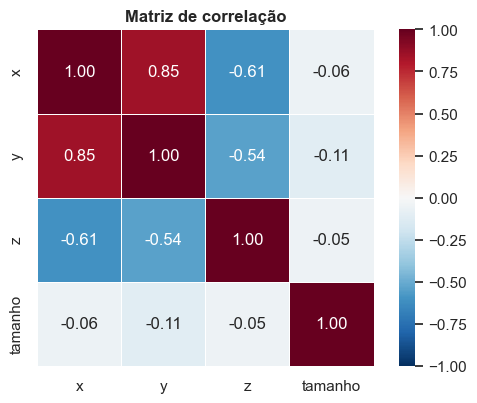

In [7]:
corr = df[["x", "y", "z", "tamanho"]].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=.5, square=True, ax=ax)
ax.set_title("Matriz de correlação")
plt.tight_layout(); plt.show()

# Parte 2 — O Visual Vocabulary por tipo de mensagem

Agora vamos percorrer as 9 categorias. Gráficos já mostrados na Parte 1 aparecem apenas com a mensagem específica daquela categoria.

## Desvio · *Deviation*

**Pergunta:** O que está acima ou abaixo de uma referência?

Enfatiza variações (+/−) em relação a um ponto fixo. Em geral a referência é zero, mas pode ser uma meta ou uma média de longo prazo. Também serve para mostrar sentimento (positivo/negativo).

### Barras divergentes · *Diverging bar*

**Mensagem:** Mostra desvios positivos e negativos em relação a um ponto de referência (zero, meta ou média).

**Quando usar:** Variações percentuais, saldo acima/abaixo da meta, diferenças entre grupos.

⚠️ **Cuidado:** Use cores diferentes para os dois lados e ordene os valores; o eixo de referência deve estar bem marcado.

*Biblioteca no exemplo: matplotlib*

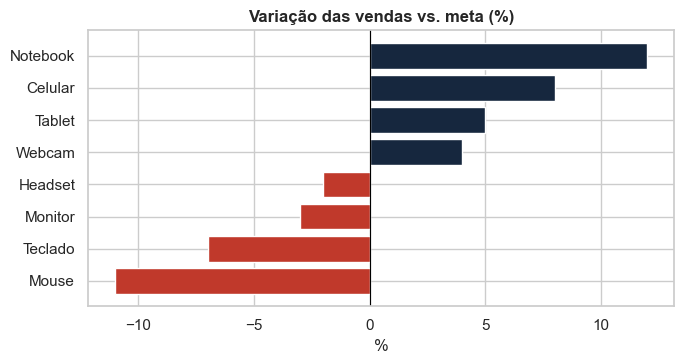

In [8]:
s = var_pct.sort_values()
cores = [RED if v < 0 else NAVY for v in s]

fig, ax = plt.subplots()
ax.barh(s.index, s.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Variação das vendas vs. meta (%)", xlabel="%")
plt.tight_layout(); plt.show()

### Barras empilhadas divergentes · *Diverging stacked bar*

**Mensagem:** Mostra opiniões ou sentimento (negativo ↔ positivo) centradas no ponto neutro.

**Quando usar:** Pesquisas de satisfação em escala Likert, avaliações.

⚠️ **Cuidado:** Centralizar a categoria neutra dificulta ler totais; use cores sequenciais consistentes.

*Biblioteca no exemplo: matplotlib*

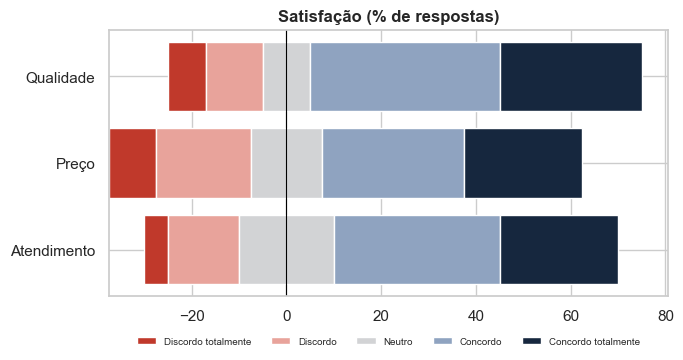

In [9]:
cols = ["Discordo totalmente", "Discordo", "Neutro", "Concordo", "Concordo totalmente"]
likert = pd.DataFrame([[5, 15, 20, 35, 25], [10, 20, 15, 30, 25], [8, 12, 10, 40, 30]],
                      columns=cols, index=["Atendimento", "Preço", "Qualidade"])
cores = [RED, "#E8A39B", GRAY, "#8FA3C0", NAVY]

left = -(likert["Discordo totalmente"] + likert["Discordo"] + likert["Neutro"] / 2)
fig, ax = plt.subplots()
for c, cor in zip(cols, cores):
    ax.barh(likert.index, likert[c], left=left, color=cor, label=c)
    left = left + likert[c]
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Satisfação (% de respostas)")
ax.legend(ncol=5, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout(); plt.show()

### Gráfico spine · *Spine chart*

**Mensagem:** Divide uma barra 100% em dois lados opostos a partir de um eixo central: proporção "sim × não".

**Quando usar:** Comparar proporções de duas respostas ou duas partes opostas entre grupos.

⚠️ **Cuidado:** Mostra apenas duas categorias; para mais categorias use barras empilhadas divergentes.

*Biblioteca no exemplo: matplotlib*

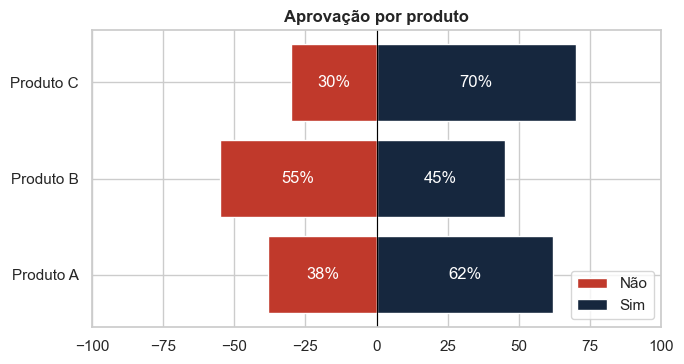

In [10]:
dados = pd.DataFrame({"Sim": [62, 45, 70], "Não": [38, 55, 30]},
                     index=["Produto A", "Produto B", "Produto C"])

fig, ax = plt.subplots()
ax.barh(dados.index, -dados["Não"], color=RED, label="Não")
ax.barh(dados.index, dados["Sim"], color=NAVY, label="Sim")
for i, (nao, sim) in enumerate(zip(dados["Não"], dados["Sim"])):
    ax.text(-nao / 2, i, f"{nao}%", ha="center", va="center", color="white")
    ax.text(sim / 2, i, f"{sim}%", ha="center", va="center", color="white")
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Aprovação por produto", xlim=(-100, 100))
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### Linha com superávit/déficit preenchido · *Surplus/deficit filled line*

**Mensagem:** Destaca a área entre uma série e sua referência, colorindo quando está acima (superávit) e abaixo (déficit).

**Quando usar:** Comparar receita × meta, saldo comercial, anomalias em relação à média.

⚠️ **Cuidado:** As duas séries devem estar na mesma unidade; use `interpolate=True` para cruzamentos suaves.

*Biblioteca no exemplo: matplotlib*

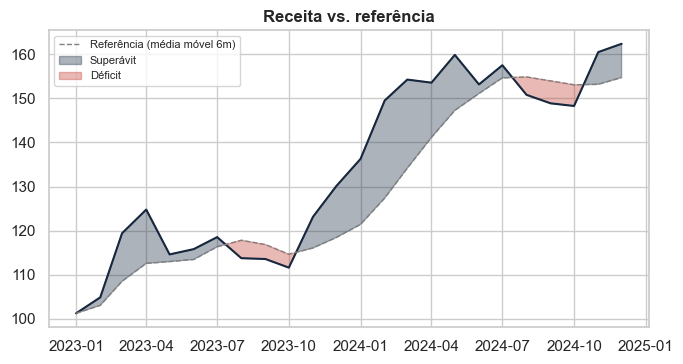

In [11]:
meta = serie["receita"].rolling(6, min_periods=1).mean()
x, y = serie["mes"], serie["receita"]

fig, ax = plt.subplots()
ax.plot(x, y, color=NAVY, lw=1.5)
ax.plot(x, meta, color="gray", ls="--", lw=1, label="Referência (média móvel 6m)")
ax.fill_between(x, y, meta, where=(y >= meta), interpolate=True, color=NAVY, alpha=0.35, label="Superávit")
ax.fill_between(x, y, meta, where=(y < meta), interpolate=True, color=RED, alpha=0.35, label="Déficit")
ax.set(title="Receita vs. referência")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Correlação · *Correlation*

**Pergunta:** As variáveis se relacionam?

Mostra a relação entre duas ou mais variáveis. Atenção: se você não avisar o contrário, muitos leitores assumem que a relação é causal.

### Mapa de calor (heatmap) · *Heatmap*

**Mensagem:** A matriz de correlação em heatmap resume a relação entre muitas variáveis de uma vez. Veja o snippet no início do notebook.

### Gráfico de dispersão (scatter) · *Scatterplot*

**Mensagem:** Mostra se duas variáveis crescem juntas, em sentidos opostos ou sem relação. Veja o snippet no início do notebook (scatter).

### Colunas + linha (timeline) · *Column + line timeline*

**Mensagem:** Relaciona duas medidas ao longo do tempo: volume (colunas) e uma segunda grandeza (linha).

**Quando usar:** Receita (colunas) × margem (linha); chuva × temperatura.

⚠️ **Cuidado:** Eixos duplos podem enganar; rotule claramente cada eixo e use cores distintas.

*Biblioteca no exemplo: matplotlib*

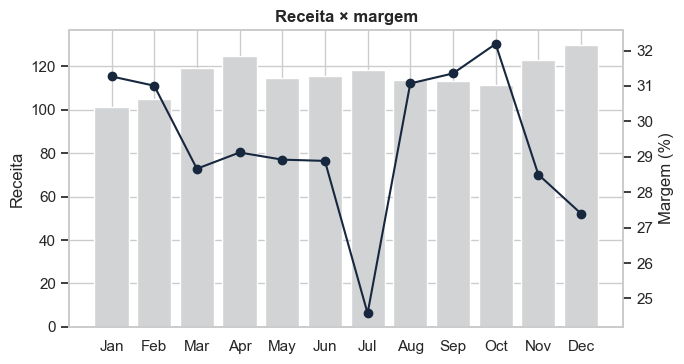

In [12]:
d = serie.head(12).copy()
d["margem"] = (d["receita"] - d["custo"]) / d["receita"] * 100

fig, ax1 = plt.subplots()
ax1.bar(d["mes"].dt.strftime("%b"), d["receita"], color=GRAY, label="Receita")
ax1.set_ylabel("Receita")
ax2 = ax1.twinx()
ax2.plot(d["mes"].dt.strftime("%b"), d["margem"], color=NAVY, marker="o", label="Margem (%)")
ax2.set_ylabel("Margem (%)")
ax2.grid(False)
ax1.set_title("Receita × margem")
plt.tight_layout(); plt.show()

### Dispersão conectada · *Connected scatterplot*

**Mensagem:** Mostra como a relação entre duas variáveis muda ao longo do tempo, ligando os pontos em ordem cronológica.

**Quando usar:** Duas variáveis acompanhadas no tempo (custo × receita, inflação × desemprego).

⚠️ **Cuidado:** Indique o início, o fim e o sentido do tempo (rótulos ou setas), senão a trajetória fica ambígua.

*Biblioteca no exemplo: matplotlib*

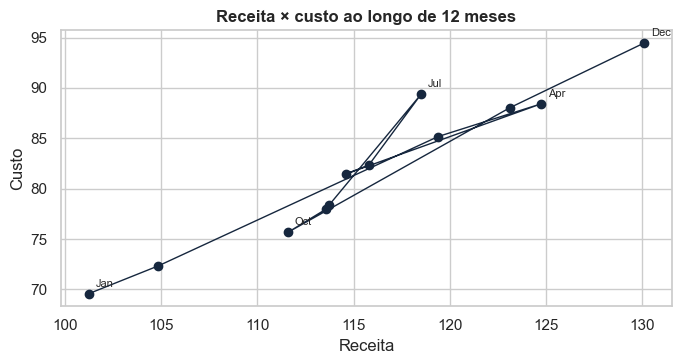

In [13]:
d = serie.head(12)

fig, ax = plt.subplots()
ax.plot(d["receita"], d["custo"], color=NAVY, marker="o", lw=1)
for i, row in d.reset_index(drop=True).iterrows():
    if i in (0, len(d) - 1) or i % 3 == 0:
        ax.annotate(row["mes"].strftime("%b"), (row["receita"], row["custo"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set(title="Receita × custo ao longo de 12 meses", xlabel="Receita", ylabel="Custo")
plt.tight_layout(); plt.show()

### Gráfico de bolhas · *Bubble chart*

**Mensagem:** Adiciona uma terceira variável numérica à dispersão através do tamanho do círculo.

**Quando usar:** Três variáveis numéricas (x, y e magnitude) — ex.: PIB × expectativa de vida × população.

⚠️ **Cuidado:** Área, não raio, deve ser proporcional ao valor; adicione legenda de tamanho.

*Biblioteca no exemplo: seaborn*

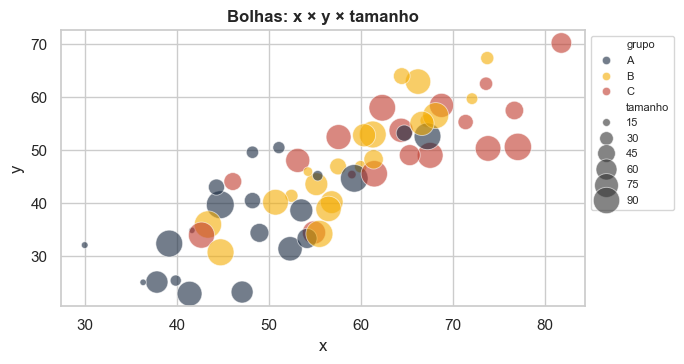

In [14]:
amostra = df.sample(60, random_state=1)

fig, ax = plt.subplots()
sns.scatterplot(data=amostra, x="x", y="y", size="tamanho", sizes=(20, 400), hue="grupo",
                palette=[NAVY, GOLD, RED], alpha=0.6, edgecolor="white", ax=ax)
ax.set(title="Bolhas: x × y × tamanho")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); plt.show()

### Heatmap XY · *XY heatmap*

**Mensagem:** Mostra a densidade ou o valor de um fenômeno em função de duas variáveis categóricas/binadas.

**Quando usar:** Dia da semana × faixa horária, faixa etária × região, densidade de pontos em x × y.

⚠️ **Cuidado:** A ordem dos eixos importa (ordene dias, horas); use escala sequencial única.

*Biblioteca no exemplo: seaborn*

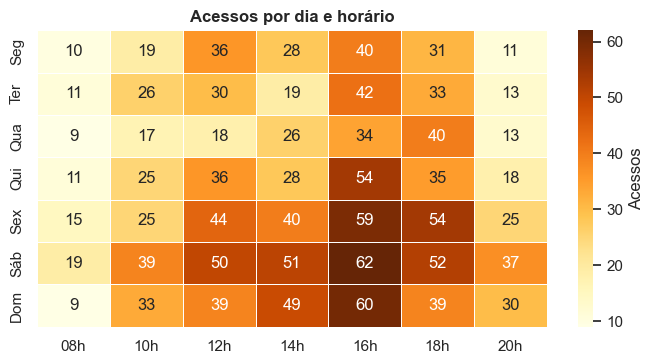

In [15]:
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
horas = [f"{h:02d}h" for h in range(8, 22, 2)]
base = np.outer([1, 1, 1, 1, 1.4, 1.8, 1.2], [1, 2, 3, 3, 4, 3, 2])
acessos = pd.DataFrame(rng.poisson(base * 10), index=dias, columns=horas)

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.heatmap(acessos, cmap="YlOrBr", annot=True, fmt="d", linewidths=.5, cbar_kws={"label": "Acessos"}, ax=ax)
ax.set(title="Acessos por dia e horário")
plt.tight_layout(); plt.show()

## Ranking · *Ranking*

**Pergunta:** Quem está na frente e quem está atrás?

Use quando a posição de um item numa lista ordenada é mais importante que seu valor absoluto ou relativo. Não tenha receio de destacar os pontos de interesse.

### Barras ordenadas · *Ordered bar*

**Mensagem:** A posição na lista importa: quem lidera e quem fica no fim.

**Quando usar:** Rankings de vendas, países, times.

⚠️ **Cuidado:** Ordene sempre; destaque (cor) o item de interesse e deixe os demais neutros.

*Biblioteca no exemplo: matplotlib*

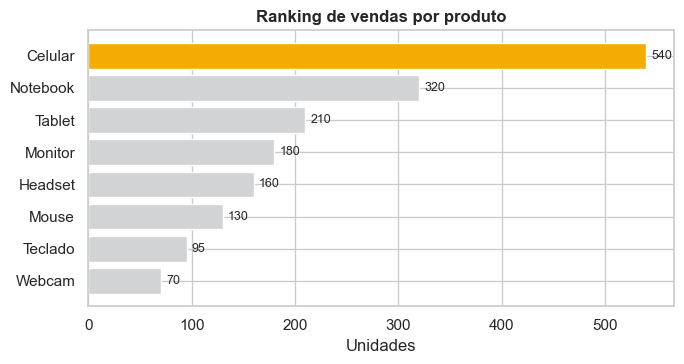

In [16]:
s = vendas_prod.sort_values()
cores = [GRAY] * len(s)
cores[-1] = GOLD

fig, ax = plt.subplots()
ax.barh(s.index, s.values, color=cores)
for i, v in enumerate(s.values):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
ax.set(title="Ranking de vendas por produto", xlabel="Unidades")
plt.tight_layout(); plt.show()

### Colunas ordenadas · *Ordered column*

**Mensagem:** Mesmo propósito das barras ordenadas, com leitura da esquerda para a direita.

**Quando usar:** Poucas categorias com rótulos curtos.

⚠️ **Cuidado:** Rótulos longos pedem barras horizontais.

*Biblioteca no exemplo: matplotlib*

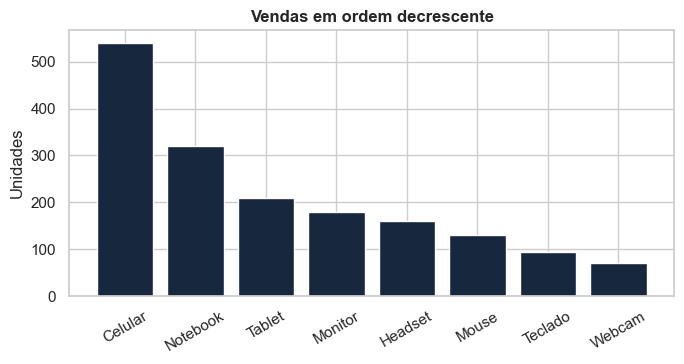

In [17]:
s = vendas_prod.sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(s.index, s.values, color=NAVY)
ax.set(title="Vendas em ordem decrescente", ylabel="Unidades")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### Símbolo proporcional ordenado · *Ordered proportional symbol*

**Mensagem:** Mostra a ordem e, ao mesmo tempo, a ordem de grandeza por meio do tamanho dos círculos.

**Quando usar:** Rankings com valores muito diferentes, em que barras ocupariam muito espaço.

⚠️ **Cuidado:** O tamanho é percebido por área; inclua o valor numérico como rótulo.

*Biblioteca no exemplo: matplotlib*

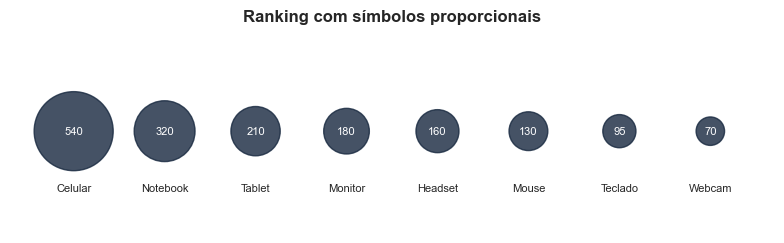

In [18]:
s = vendas_prod.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.scatter(range(len(s)), [0] * len(s), s=s.values * 6, color=NAVY, alpha=0.8)
for i, (nome, v) in enumerate(s.items()):
    ax.text(i, -0.35, nome, ha="center", fontsize=8)
    ax.text(i, 0, str(v), ha="center", va="center", color="white", fontsize=8)
ax.set(xlim=(-0.7, len(s) - 0.3), ylim=(-0.6, 0.6), title="Ranking com símbolos proporcionais")
ax.axis("off")
plt.tight_layout(); plt.show()

### Dot strip plot · *Dot strip plot*

**Mensagem:** Mostra cada observação como ponto em uma faixa por categoria: valores individuais e ranking de grupos.

**Quando usar:** Comparar grupos preservando todos os dados (notas por turma, preços por categoria).

⚠️ **Cuidado:** Use jitter e transparência para evitar sobreposição.

*Biblioteca no exemplo: seaborn*

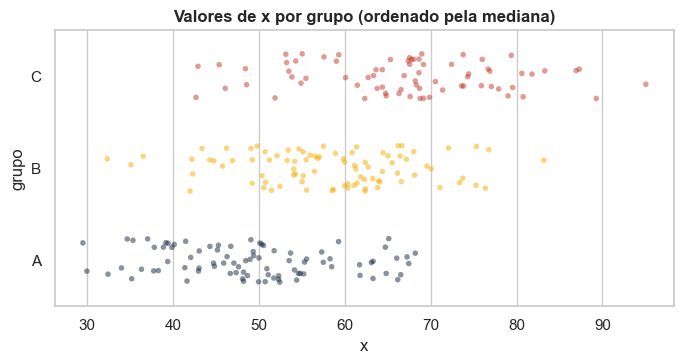

In [19]:
ordem = df.groupby("grupo")["x"].median().sort_values(ascending=False).index

fig, ax = plt.subplots()
sns.stripplot(data=df, x="x", y="grupo", order=ordem, hue="grupo", hue_order=["A", "B", "C"], palette=[NAVY, GOLD, RED],
              alpha=0.5, size=4, jitter=0.25, legend=False, ax=ax)
ax.set(title="Valores de x por grupo (ordenado pela mediana)")
plt.tight_layout(); plt.show()

### Slopegraph · *Slope chart*

**Mensagem:** Compara a mudança de posição ou valor entre dois momentos para cada item.

**Quando usar:** Antes × depois, ano × ano, ranking em dois períodos.

⚠️ **Cuidado:** Funciona bem com até ~10 itens; use rótulos nas pontas e destaque as inclinações relevantes.

*Biblioteca no exemplo: matplotlib*

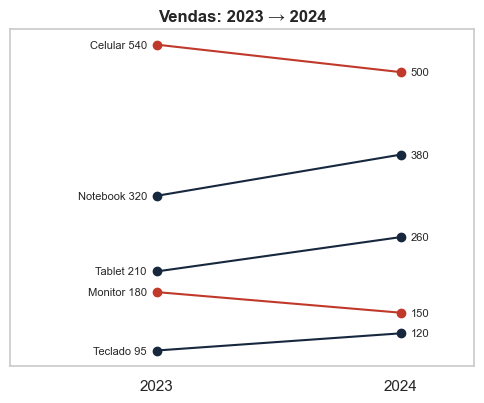

In [20]:
d = pd.DataFrame({"2023": [320, 540, 210, 180, 95], "2024": [380, 500, 260, 150, 120]},
                 index=["Notebook", "Celular", "Tablet", "Monitor", "Teclado"])

fig, ax = plt.subplots(figsize=(5, 4.2))
for nome, row in d.iterrows():
    cor = NAVY if row["2024"] >= row["2023"] else RED
    ax.plot([0, 1], [row["2023"], row["2024"]], marker="o", color=cor)
    ax.text(-0.04, row["2023"], f"{nome} {row['2023']}", ha="right", va="center", fontsize=8)
    ax.text(1.04, row["2024"], f"{row['2024']}", ha="left", va="center", fontsize=8)
ax.set(xlim=(-0.6, 1.3), xticks=[0, 1], xticklabels=["2023", "2024"], title="Vendas: 2023 → 2024")
ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

### Gráfico de pirulito · *Lollipop chart*

**Mensagem:** Variante mais leve das barras: destaca o valor final (ponto) com menos tinta.

**Quando usar:** Rankings ou comparações com muitas categorias.

⚠️ **Cuidado:** Mantenha a base em zero, como nas barras.

*Biblioteca no exemplo: matplotlib*

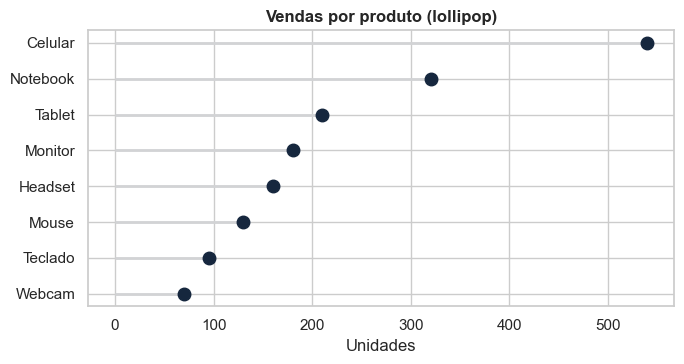

In [21]:
s = vendas_prod.sort_values()

fig, ax = plt.subplots()
ax.hlines(y=s.index, xmin=0, xmax=s.values, color=GRAY, lw=2)
ax.plot(s.values, s.index, "o", color=NAVY, ms=9)
ax.set(title="Vendas por produto (lollipop)", xlabel="Unidades")
plt.tight_layout(); plt.show()

### Bump chart · *Bump chart*

**Mensagem:** Mostra a variação de posições (ranking) de vários itens ao longo de períodos.

**Quando usar:** Ranking trimestral de produtos, classificações de campeonato.

⚠️ **Cuidado:** O eixo y é a posição (1 = melhor, no topo); destaque só alguns itens.

*Biblioteca no exemplo: matplotlib*

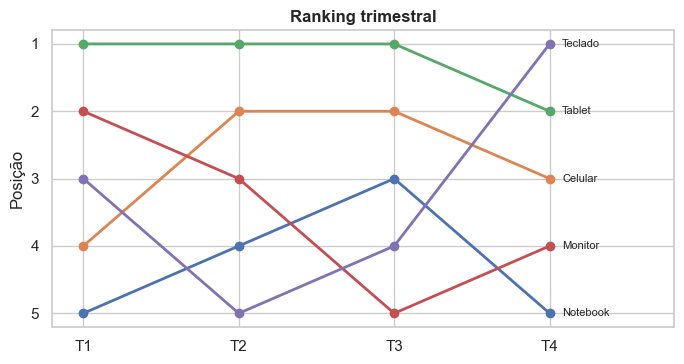

In [22]:
trim = ["T1", "T2", "T3", "T4"]
v = pd.DataFrame(rng.integers(50, 300, (5, 4)), columns=trim,
                 index=["Notebook", "Celular", "Tablet", "Monitor", "Teclado"])
rank = v.rank(ascending=False).astype(int)

fig, ax = plt.subplots()
for nome in rank.index:
    ax.plot(trim, rank.loc[nome], marker="o", lw=2, label=nome)
    ax.text(3.08, rank.loc[nome].iloc[-1], nome, va="center", fontsize=8)
ax.invert_yaxis()
ax.set(yticks=range(1, 6), ylabel="Posição", title="Ranking trimestral", xlim=(-0.2, 3.8))
plt.tight_layout(); plt.show()

## Distribuição · *Distribution*

**Pergunta:** Como os valores se espalham e com que frequência ocorrem?

Mostra os valores de um conjunto de dados e a frequência com que ocorrem. A forma (assimetria) da distribuição pode destacar a falta de uniformidade ou de igualdade nos dados.

### Histograma · *Histogram*

**Mensagem:** O histograma é o ponto de partida para ver a forma de uma distribuição. Veja o snippet no início do notebook.

### Dot plot (Wilkinson) · *Dot plot*

**Mensagem:** Cada observação é um ponto empilhado em seu bin: mostra forma da distribuição e contagem exata.

**Quando usar:** Poucos dados (dezenas) em que cada observação importa.

⚠️ **Cuidado:** Com muitos dados os pontos ficam inviáveis: use histograma.

*Biblioteca no exemplo: matplotlib*

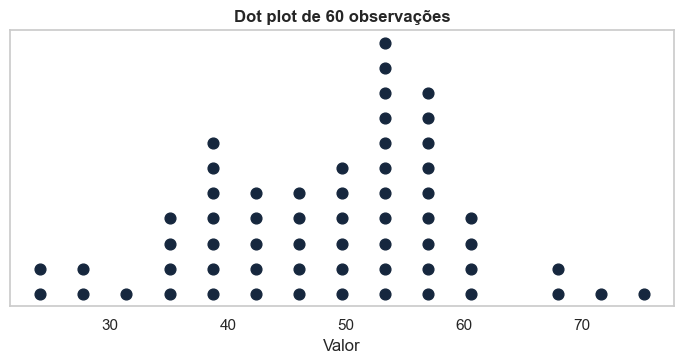

In [23]:
vals = rng.normal(50, 10, 60)
cont, bordas = np.histogram(vals, bins=15)
centros = (bordas[:-1] + bordas[1:]) / 2

fig, ax = plt.subplots()
for c, k in zip(centros, cont):
    ax.scatter([c] * k, range(1, k + 1), color=NAVY, s=60)
ax.set(title="Dot plot de 60 observações", xlabel="Valor", yticks=[])
ax.grid(False)
plt.tight_layout(); plt.show()

### Dot strip plot · *Dot strip plot*

**Mensagem:** Cada observação vira um ponto: mostra a distribuição sem esconder os dados. Veja o snippet em Ranking.

### Barcode plot · *Barcode plot*

**Mensagem:** Cada observação vira um traço vertical: revela concentrações e lacunas sem agrupar em bins.

**Quando usar:** Comparar distribuições de poucos grupos de forma compacta.

⚠️ **Cuidado:** Traços muito próximos se sobrepõem; use transparência.

*Biblioteca no exemplo: matplotlib*

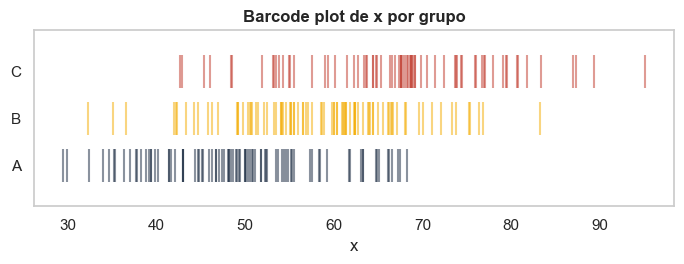

In [24]:
fig, ax = plt.subplots(figsize=(7, 2.8))
grupos = sorted(df["grupo"].unique())
for i, g in enumerate(grupos):
    ax.eventplot(df.loc[df["grupo"] == g, "x"].values, lineoffsets=i, linelengths=0.7,
                 colors=[NAVY, GOLD, RED][i], alpha=0.5)
ax.set(yticks=range(len(grupos)), yticklabels=grupos, title="Barcode plot de x por grupo", xlabel="x")
ax.grid(False)
plt.tight_layout(); plt.show()

### Boxplot · *Boxplot*

**Mensagem:** Resume a distribuição: mediana, quartis, amplitude e outliers.

**Quando usar:** Comparar distribuições de vários grupos de modo compacto.

⚠️ **Cuidado:** Esconde a forma (bimodalidade); combine com pontos (strip/swarm) quando possível.

*Biblioteca no exemplo: matplotlib + seaborn*

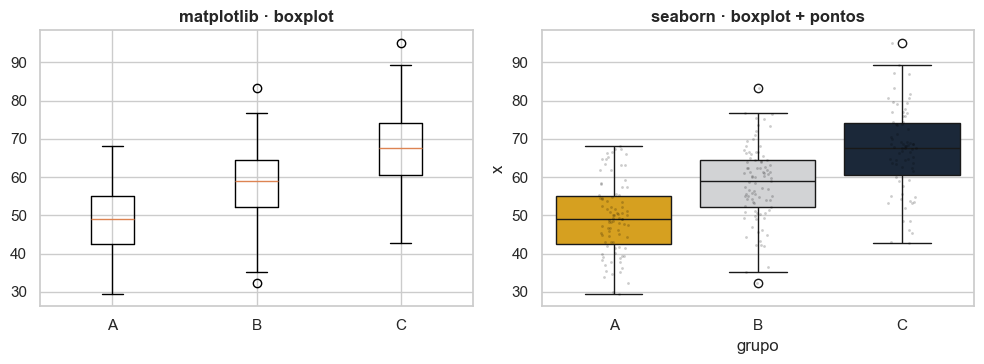

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].boxplot([df.loc[df.grupo == g, "x"] for g in ["A", "B", "C"]])
axes[0].set(title="matplotlib · boxplot", xticklabels=["A", "B", "C"])

sns.boxplot(data=df, x="grupo", y="x", order=["A", "B", "C"], hue="grupo", palette=[NAVY, GOLD, GRAY], legend=False, ax=axes[1])
sns.stripplot(data=df, x="grupo", y="x", order=["A", "B", "C"], color="black", alpha=0.2, size=2, ax=axes[1])
axes[1].set(title="seaborn · boxplot + pontos")
plt.tight_layout(); plt.show()

### Violin plot · *Violin plot*

**Mensagem:** Combina boxplot com densidade (KDE): mostra a forma completa da distribuição.

**Quando usar:** Comparar grupos com distribuições possivelmente multimodais.

⚠️ **Cuidado:** Para amostras pequenas o KDE pode sugerir formas inexistentes.

*Biblioteca no exemplo: seaborn*

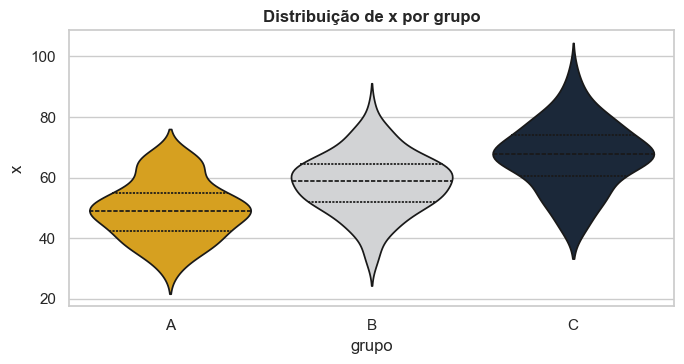

In [26]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="grupo", y="x", order=["A", "B", "C"], hue="grupo", palette=[NAVY, GOLD, GRAY],
               inner="quartile", legend=False, ax=ax)
ax.set(title="Distribuição de x por grupo")
plt.tight_layout(); plt.show()

### Pirâmide populacional · *Population pyramid*

**Mensagem:** Compara a distribuição de duas categorias (ex.: homens × mulheres) por faixas, lado a lado.

**Quando usar:** Estrutura etária, comparação de dois grupos em faixas ordenadas.

⚠️ **Cuidado:** Use a mesma escala nos dois lados e mostre valores absolutos como positivos.

*Biblioteca no exemplo: matplotlib*

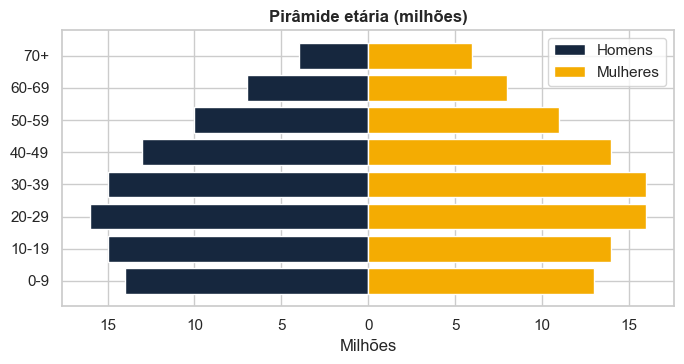

In [27]:
faixas = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
homens = np.array([14, 15, 16, 15, 13, 10, 7, 4])
mulheres = np.array([13, 14, 16, 16, 14, 11, 8, 6])

fig, ax = plt.subplots()
ax.barh(faixas, -homens, color=NAVY, label="Homens")
ax.barh(faixas, mulheres, color=GOLD, label="Mulheres")
ax.set_xticks([-15, -10, -5, 0, 5, 10, 15])
ax.set_xticklabels([15, 10, 5, 0, 5, 10, 15])
ax.set(title="Pirâmide etária (milhões)", xlabel="Milhões")
ax.legend()
plt.tight_layout(); plt.show()

### Curva acumulada · *Cumulative curve*

**Mensagem:** Mostra a proporção de observações abaixo de cada valor: percentis, medianas e comparação entre grupos.

**Quando usar:** Responder "que % está abaixo de X?" e comparar distribuições sem escolher bins.

⚠️ **Cuidado:** Menos intuitiva para o público geral; explique como ler.

*Biblioteca no exemplo: seaborn*

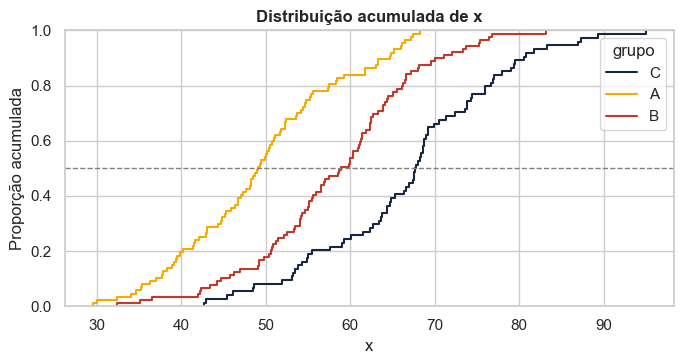

In [28]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df, x="x", hue="grupo", palette=[NAVY, GOLD, RED], ax=ax)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set(title="Distribuição acumulada de x", ylabel="Proporção acumulada")
plt.tight_layout(); plt.show()

### Polígono de frequências · *Frequency polygon*

**Mensagem:** Linhas ligando as frequências de cada classe: facilita sobrepor várias distribuições.

**Quando usar:** Comparar duas ou três distribuições no mesmo gráfico.

⚠️ **Cuidado:** Use os mesmos bins para todos os grupos.

*Biblioteca no exemplo: matplotlib*

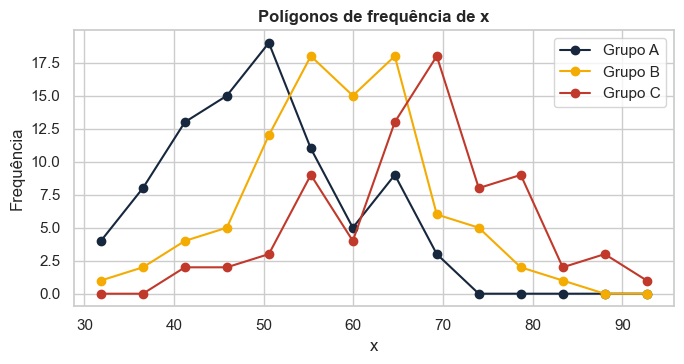

In [29]:
bins = np.linspace(df["x"].min(), df["x"].max(), 15)
centros = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots()
for g, cor in zip(["A", "B", "C"], [NAVY, GOLD, RED]):
    cont, _ = np.histogram(df.loc[df.grupo == g, "x"], bins=bins)
    ax.plot(centros, cont, marker="o", color=cor, label=f"Grupo {g}")
ax.set(title="Polígonos de frequência de x", xlabel="x", ylabel="Frequência")
ax.legend()
plt.tight_layout(); plt.show()

### Beeswarm · *Beeswarm*

**Mensagem:** Mostra todos os pontos sem sobreposição, formando um "enxame" cuja largura indica densidade.

**Quando usar:** Amostras pequenas/médias (até ~200 pontos por grupo).

⚠️ **Cuidado:** Com muitos pontos, o seaborn avisa que não consegue posicionar todos: use violin ou strip.

*Biblioteca no exemplo: seaborn*

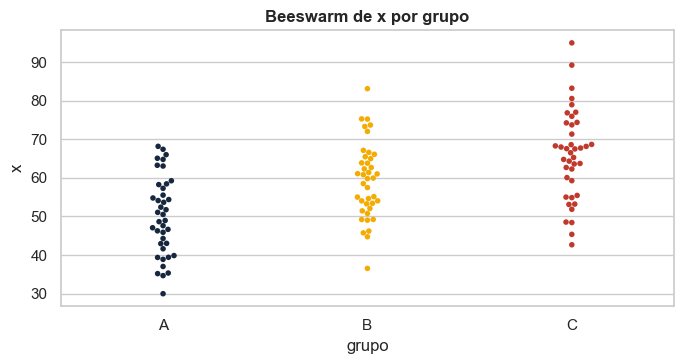

In [30]:
amostra = df.groupby("grupo").sample(40, random_state=1)

fig, ax = plt.subplots()
sns.swarmplot(data=amostra, x="grupo", y="x", order=["A", "B", "C"], hue="grupo", palette=[NAVY, GOLD, RED], size=4,
              legend=False, ax=ax)
ax.set(title="Beeswarm de x por grupo")
plt.tight_layout(); plt.show()

## Evolução no tempo · *Change over Time*

**Pergunta:** Como isso mudou ao longo do tempo?

Dá ênfase a tendências em mudança. Podem ser movimentos curtos (intradiários) ou séries longas (décadas ou séculos): escolher o período correto dá o contexto adequado ao leitor.

### Gráfico de linhas · *Line chart*

**Mensagem:** A linha é o gráfico padrão de evolução temporal. Veja o snippet no início do notebook.

### Colunas no tempo · *Column chart*

**Mensagem:** Mostra valores discretos por período (mês, trimestre, ano): bom para comparar períodos individuais.

**Quando usar:** Poucos períodos; valores que são totais de cada intervalo.

⚠️ **Cuidado:** Com muitos períodos, linhas são mais legíveis.

*Biblioteca no exemplo: matplotlib*

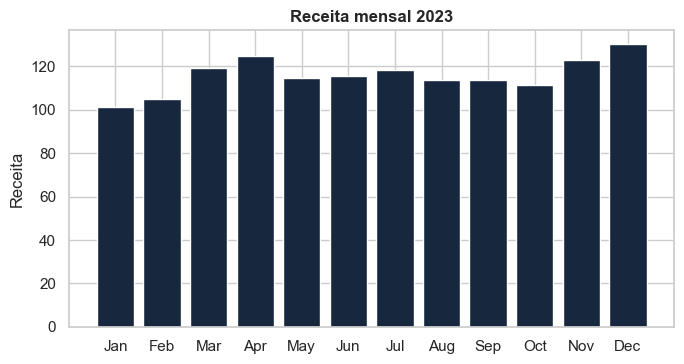

In [31]:
d = serie.head(12)

fig, ax = plt.subplots()
ax.bar(d["mes"].dt.strftime("%b"), d["receita"], color=NAVY)
ax.set(title="Receita mensal 2023", ylabel="Receita")
plt.tight_layout(); plt.show()

### Colunas + linha (timeline) · *Column + line timeline*

**Mensagem:** Compara o volume (colunas) com outra grandeza (linha) no tempo. Veja o snippet em Correlação.

### Slopegraph · *Slope chart*

**Mensagem:** Compara dois momentos no tempo para cada item. Veja o snippet em Ranking.

### Gráfico de área · *Area chart*

**Mensagem:** Linha com preenchimento: enfatiza o volume acumulado ao longo do tempo.

**Quando usar:** Uma série para dar peso visual ou séries empilhadas para a composição ao longo do tempo.

⚠️ **Cuidado:** Evite áreas sobrepostas (opacas); prefira empilhar ou usar transparência.

*Biblioteca no exemplo: matplotlib*

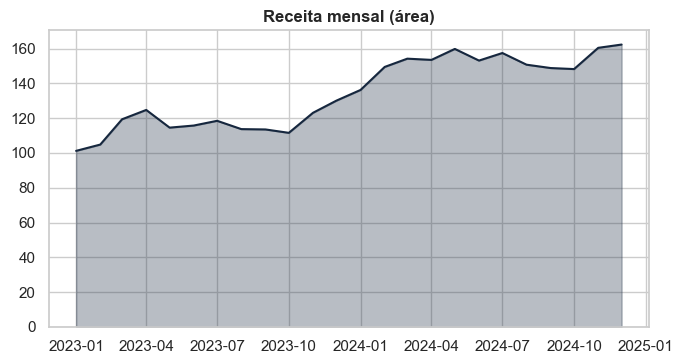

In [32]:
fig, ax = plt.subplots()
ax.fill_between(serie["mes"], serie["receita"], color=NAVY, alpha=0.3)
ax.plot(serie["mes"], serie["receita"], color=NAVY)
ax.set(title="Receita mensal (área)", ylim=(0, None))
plt.tight_layout(); plt.show()

### Candlestick · *Candlestick*

**Mensagem:** Mostra abertura, fechamento, máxima e mínima de cada período (padrão em finanças).

**Quando usar:** Preços de ações, câmbio, commodities.

⚠️ **Cuidado:** Exige cuidado com a cor (alta/baixa) para daltônicos; combine com volume.

*Biblioteca no exemplo: matplotlib*

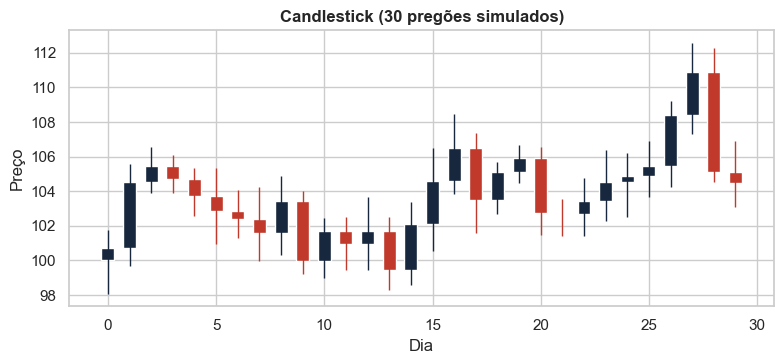

In [33]:
n_d = 30
fech = 100 + np.cumsum(rng.normal(0, 2, n_d))
aber = np.r_[100, fech[:-1]]
alta = np.maximum(aber, fech) + rng.uniform(0.5, 2, n_d)
baixa = np.minimum(aber, fech) - rng.uniform(0.5, 2, n_d)
cor = np.where(fech >= aber, NAVY, RED)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.vlines(range(n_d), baixa, alta, color=cor, lw=1)
ax.bar(range(n_d), fech - aber, bottom=aber, color=cor, width=0.6)
ax.set(title="Candlestick (30 pregões simulados)", xlabel="Dia", ylabel="Preço")
plt.tight_layout(); plt.show()

### Fan chart (projeções) · *Fan chart*

**Mensagem:** Mostra a incerteza de uma projeção: o leque se alarga conforme o horizonte aumenta.

**Quando usar:** Previsões de inflação, PIB, vendas.

⚠️ **Cuidado:** Explique o que representam as faixas (intervalos de confiança).

*Biblioteca no exemplo: matplotlib*

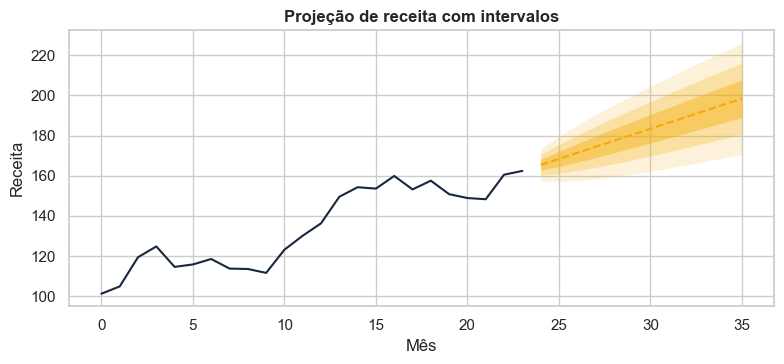

In [34]:
hist = serie["receita"].values
h = np.arange(1, 13)
centro = hist[-1] + 3 * h
sigma = 4 * np.sqrt(h)
x_hist = np.arange(len(hist))
x_fut = len(hist) - 1 + h

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(x_hist, hist, color=NAVY)
for k, a in zip([2.0, 1.28, 0.67], [0.15, 0.25, 0.4]):
    ax.fill_between(x_fut, centro - k * sigma, centro + k * sigma, color=GOLD, alpha=a, lw=0)
ax.plot(x_fut, centro, color=GOLD, ls="--")
ax.set(title="Projeção de receita com intervalos", xlabel="Mês", ylabel="Receita")
plt.tight_layout(); plt.show()

### Dispersão conectada · *Connected scatterplot*

**Mensagem:** Mostra a trajetória de duas variáveis ao longo do tempo. Veja o snippet em Correlação.

### Calendar heatmap · *Calendar heatmap*

**Mensagem:** Cor por dia em uma grade semana × dia da semana: padrões sazonais e de rotina.

**Quando usar:** Atividade diária (commits, vendas, acessos).

⚠️ **Cuidado:** Escala de cor deve ter contraste suficiente; dias sem dados devem ficar claros.

*Biblioteca no exemplo: seaborn*

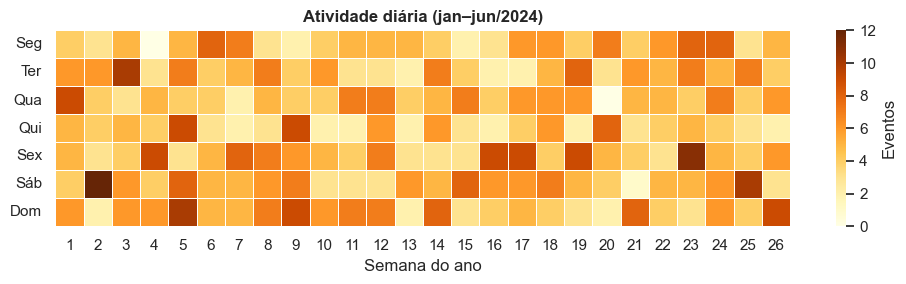

In [35]:
dias = pd.date_range("2024-01-01", "2024-06-30")
cal = pd.DataFrame({"data": dias, "v": rng.poisson(5, len(dias))})
cal["semana"] = cal["data"].dt.isocalendar().week.astype(int)
cal["dow"] = cal["data"].dt.dayofweek
mat = cal.pivot(index="dow", columns="semana", values="v")

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(mat, cmap="YlOrBr", cbar_kws={"label": "Eventos"}, linewidths=.5, ax=ax,
            yticklabels=["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"])
ax.set(title="Atividade diária (jan–jun/2024)", xlabel="Semana do ano", ylabel="")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

### Priestley timeline · *Priestley timeline*

**Mensagem:** Barras horizontais mostram a duração (início–fim) de cada item numa linha do tempo.

**Quando usar:** Vida de pessoas, vigência de projetos, mandatos.

⚠️ **Cuidado:** Ordene por data de início para facilitar a leitura.

*Biblioteca no exemplo: matplotlib*

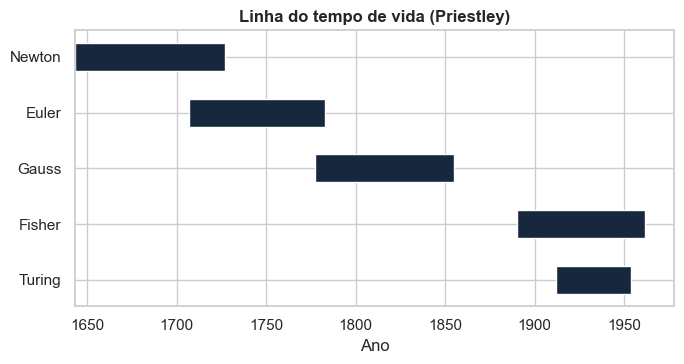

In [36]:
vidas = pd.DataFrame({"nome": ["Newton", "Euler", "Gauss", "Fisher", "Turing"],
                      "ini": [1643, 1707, 1777, 1890, 1912],
                      "fim": [1727, 1783, 1855, 1962, 1954]})

fig, ax = plt.subplots()
ax.barh(vidas["nome"], vidas["fim"] - vidas["ini"], left=vidas["ini"], color=NAVY, height=0.5)
ax.invert_yaxis()
ax.set(title="Linha do tempo de vida (Priestley)", xlabel="Ano")
plt.tight_layout(); plt.show()

### Linha do tempo com círculos · *Circle timeline*

**Mensagem:** Eventos sobre uma linha, com o tamanho do círculo indicando a importância ou magnitude.

**Quando usar:** Eventos pontuais com intensidades diferentes (terremotos, lançamentos).

⚠️ **Cuidado:** Alterne rótulos acima/abaixo para evitar sobreposição.

*Biblioteca no exemplo: matplotlib*

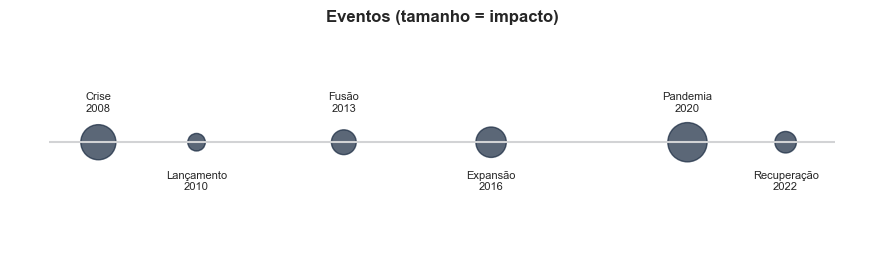

In [37]:
ev = pd.DataFrame({"ano": [2008, 2010, 2013, 2016, 2020, 2022],
                   "nome": ["Crise", "Lançamento", "Fusão", "Expansão", "Pandemia", "Recuperação"],
                   "peso": [80, 20, 40, 60, 100, 30]})

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.hlines(0, 2007, 2023, color=GRAY)
ax.scatter(ev["ano"], [0] * len(ev), s=ev["peso"] * 8, color=NAVY, alpha=0.7)
for i, r in ev.iterrows():
    ax.text(r["ano"], 0.35 if i % 2 == 0 else -0.35, f"{r['nome']}\n{r['ano']}",
            ha="center", va="center", fontsize=8)
ax.set(ylim=(-1, 1), title="Eventos (tamanho = impacto)")
ax.axis("off")
plt.tight_layout(); plt.show()

### Linha do tempo vertical · *Vertical timeline*

**Mensagem:** Sequência de marcos de cima para baixo, ideal para narrativas e leitura em telas estreitas.

**Quando usar:** Histórico de um projeto, cronologia de eventos.

⚠️ **Cuidado:** Inclua datas legíveis e textos curtos.

*Biblioteca no exemplo: matplotlib*

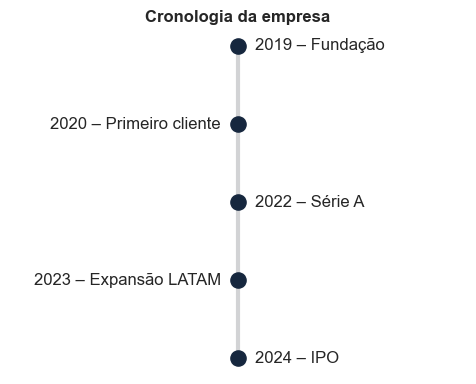

In [38]:
marcos = [("2019", "Fundação"), ("2020", "Primeiro cliente"), ("2022", "Série A"),
          ("2023", "Expansão LATAM"), ("2024", "IPO")]

fig, ax = plt.subplots(figsize=(5, 4))
ax.vlines(0, 0, len(marcos) - 1, color=GRAY, lw=3)
for i, (ano, txt) in enumerate(marcos):
    ax.scatter(0, i, s=120, color=NAVY, zorder=3)
    lado = 1 if i % 2 == 0 else -1
    ax.text(0.15 * lado, i, f"{ano} – {txt}", ha="left" if lado > 0 else "right", va="center")
ax.invert_yaxis()
ax.set(xlim=(-2, 2), title="Cronologia da empresa")
ax.axis("off")
plt.tight_layout(); plt.show()

### Sismograma · *Seismogram*

**Mensagem:** Mostra picos e vales de uma grandeza que oscila em torno de zero, evidenciando períodos de volatilidade.

**Quando usar:** Retornos diários, anomalias, variações em relação à média.

⚠️ **Cuidado:** Use escala simétrica e destaque os períodos extremos.

*Biblioteca no exemplo: matplotlib*

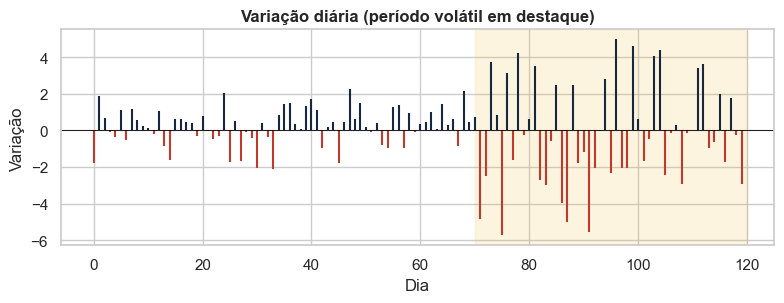

In [39]:
dias = np.arange(120)
vol = np.where(dias > 70, 3.0, 1.0)
ret = rng.normal(0, 1, 120) * vol

fig, ax = plt.subplots(figsize=(8, 3.2))
cores = np.where(ret >= 0, NAVY, RED)
ax.vlines(dias, 0, ret, color=cores, lw=1.5)
ax.axhline(0, color="black", lw=0.6)
ax.axvspan(70, 120, color=GOLD, alpha=0.12)
ax.set(title="Variação diária (período volátil em destaque)", xlabel="Dia", ylabel="Variação")
plt.tight_layout(); plt.show()

### Streamgraph · *Streamgraph*

**Mensagem:** Áreas empilhadas com base ondulada: mostra a evolução de várias categorias e o fluxo de seu peso relativo.

**Quando usar:** Muitas séries com comportamento sazonal (gêneros musicais, tópicos em notícias).

⚠️ **Cuidado:** Mais estético que preciso: valores absolutos são difíceis de ler.

*Biblioteca no exemplo: matplotlib*

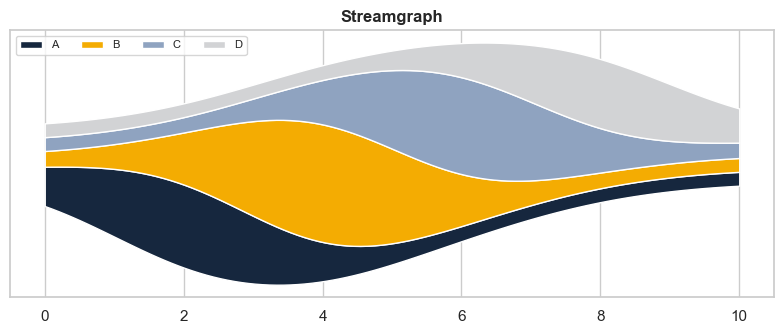

In [40]:
x = np.linspace(0, 10, 100)
series = [np.exp(-(x - c) ** 2 / 4) * a + 0.2 for c, a in [(2, 1), (4, 1.5), (6, 1.2), (8, 0.8)]]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.stackplot(x, series, baseline="wiggle", colors=[NAVY, GOLD, "#8FA3C0", GRAY],
             labels=["A", "B", "C", "D"])
ax.legend(loc="upper left", ncol=4, fontsize=8)
ax.set(title="Streamgraph", yticks=[])
plt.tight_layout(); plt.show()

## Magnitude · *Magnitude*

**Pergunta:** Qual é o tamanho de cada coisa?

Mostra comparações de tamanho. Podem ser relativas (apenas ver quem é maior/menor) ou absolutas (precisar ver números exatos).

### Gráfico de barras / colunas · *Bar / Column chart*

**Mensagem:** Colunas e barras são a escolha padrão para comparar magnitudes. Veja o snippet no início do notebook.

### Colunas pareadas · *Paired column*

**Mensagem:** Compara dois valores (ex.: dois anos) lado a lado para cada categoria.

**Quando usar:** Comparação entre dois períodos ou cenários em poucas categorias.

⚠️ **Cuidado:** Com mais de duas séries, o gráfico fica pesado: use barras ou lollipop.

*Biblioteca no exemplo: seaborn*

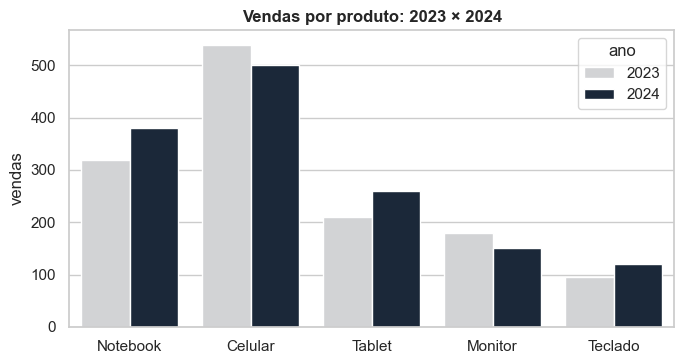

In [41]:
d = pd.DataFrame({"produto": ["Notebook", "Celular", "Tablet", "Monitor", "Teclado"] * 2,
                  "ano": ["2023"] * 5 + ["2024"] * 5,
                  "vendas": [320, 540, 210, 180, 95, 380, 500, 260, 150, 120]})

fig, ax = plt.subplots()
sns.barplot(data=d, x="produto", y="vendas", hue="ano", palette=[GRAY, NAVY], ax=ax)
ax.set(title="Vendas por produto: 2023 × 2024", xlabel="")
plt.tight_layout(); plt.show()

### Barras pareadas · *Paired bar*

**Mensagem:** Versão horizontal das colunas pareadas, melhor para rótulos longos.

**Quando usar:** Dois valores por categoria com nomes extensos.

⚠️ **Cuidado:** Mantenha a mesma ordem das categorias.

*Biblioteca no exemplo: pandas/matplotlib*

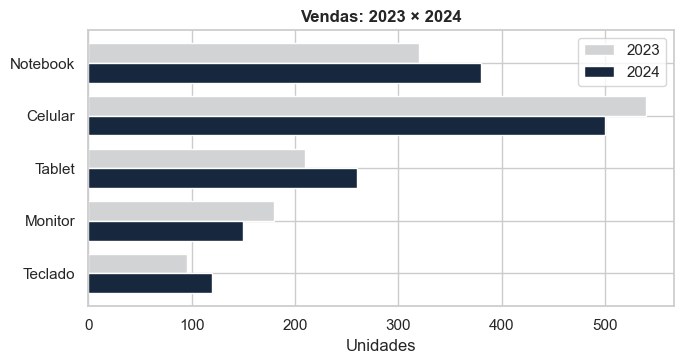

In [42]:
d = pd.DataFrame({"2023": [320, 540, 210, 180, 95], "2024": [380, 500, 260, 150, 120]},
                 index=["Notebook", "Celular", "Tablet", "Monitor", "Teclado"])

ax = d.plot.barh(color=[GRAY, NAVY], figsize=(7, 3.8), width=0.75)
ax.invert_yaxis()
ax.set(title="Vendas: 2023 × 2024", xlabel="Unidades")
plt.tight_layout(); plt.show()

### Marimekko (Mekko) · *Marimekko*

**Mensagem:** Colunas de larguras variáveis: largura = tamanho do segmento, altura = composição interna.

**Quando usar:** Mercado por região (largura) e participação por produto (altura).

⚠️ **Cuidado:** Complexo de ler; use poucos segmentos e rótulos diretos.

*Biblioteca no exemplo: matplotlib*

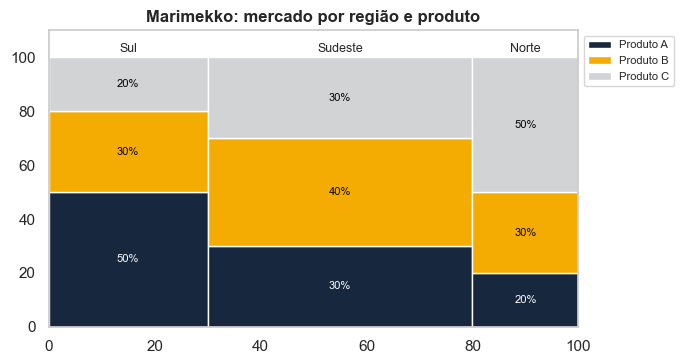

In [43]:
regioes = ["Sul", "Sudeste", "Norte"]
larg = np.array([30, 50, 20])
share = np.array([[50, 30, 20], [30, 40, 30], [20, 30, 50]])  # cada linha soma 100
prod = ["Produto A", "Produto B", "Produto C"]
cores = [NAVY, GOLD, GRAY]
x0 = np.r_[0, np.cumsum(larg)[:-1]]

fig, ax = plt.subplots()
for i, (xi, w) in enumerate(zip(x0, larg)):
    base = 0
    for j, s in enumerate(share[i]):
        ax.bar(xi, s, width=w, bottom=base, align="edge", color=cores[j],
               edgecolor="white", label=prod[j] if i == 0 else None)
        ax.text(xi + w / 2, base + s / 2, f"{s}%", ha="center", va="center", fontsize=8,
                color="white" if j == 0 else "black")
        base += s
    ax.text(xi + w / 2, 102, regioes[i], ha="center", fontsize=9)
ax.set(xlim=(0, 100), ylim=(0, 110), title="Marimekko: mercado por região e produto")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8); ax.grid(False)
plt.tight_layout(); plt.show()

### Símbolos proporcionais · *Proportional symbol*

**Mensagem:** Círculos cuja área representa o valor: comparam magnitudes em lugares ou categorias.

**Quando usar:** Valores em posições (cidades) ou categorias com grande amplitude de valores.

⚠️ **Cuidado:** Legenda de tamanhos obrigatória; evite sobreposição.

*Biblioteca no exemplo: matplotlib*

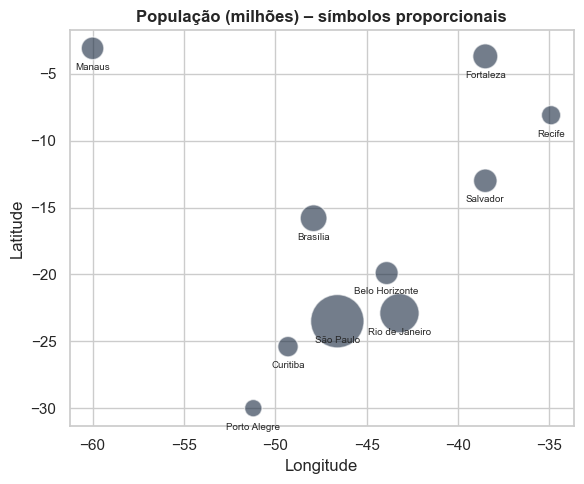

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cidades["lon"], cidades["lat"], s=cidades["pop"] * 120, color=NAVY, alpha=0.6, edgecolor="white")
for _, r in cidades.iterrows():
    ax.text(r["lon"], r["lat"] - 1.6, r["nome"], ha="center", fontsize=7)
ax.set(title="População (milhões) – símbolos proporcionais", xlabel="Longitude", ylabel="Latitude")
plt.tight_layout(); plt.show()

### Isotype (pictograma) · *Isotype*

**Mensagem:** Repete símbolos para representar quantidades de forma intuitiva (1 símbolo = N unidades).

**Quando usar:** Comunicação para públicos gerais; contagens pequenas.

⚠️ **Cuidado:** Indique o valor de cada símbolo; símbolos parciais enganam.

*Biblioteca no exemplo: matplotlib*

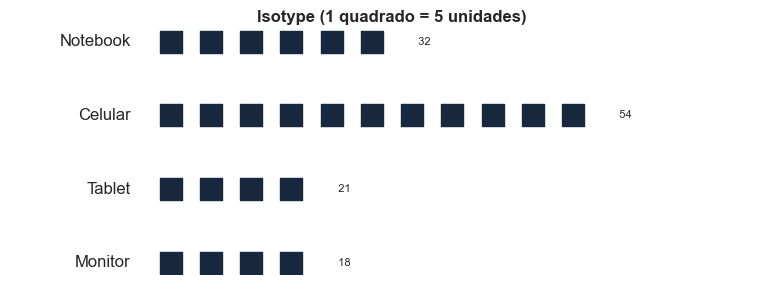

In [45]:
dados = {"Notebook": 32, "Celular": 54, "Tablet": 21, "Monitor": 18}
un = 5  # 1 símbolo = 5 unidades

fig, ax = plt.subplots(figsize=(8, 3))
for i, (nome, v) in enumerate(dados.items()):
    k = round(v / un)
    ax.scatter(range(k), [i] * k, s=250, marker="s", color=NAVY)
    ax.text(-1, i, nome, ha="right", va="center")
    ax.text(k, i, f"  {v}", va="center", fontsize=8)
ax.invert_yaxis()
ax.set(xlim=(-4, 15), title=f"Isotype (1 quadrado = {un} unidades)")
ax.axis("off")
plt.tight_layout(); plt.show()

### Gráfico de pirulito · *Lollipop chart*

**Mensagem:** Variante leve de barras. Veja o snippet em Ranking.

### Radar (teia) · *Radar chart*

**Mensagem:** Compara vários atributos de poucas entidades em eixos radiais.

**Quando usar:** Perfis multidimensionais (avaliação de produtos, competências).

⚠️ **Cuidado:** A área e a ordem dos eixos distorcem a leitura; use com poucas séries.

*Biblioteca no exemplo: matplotlib*

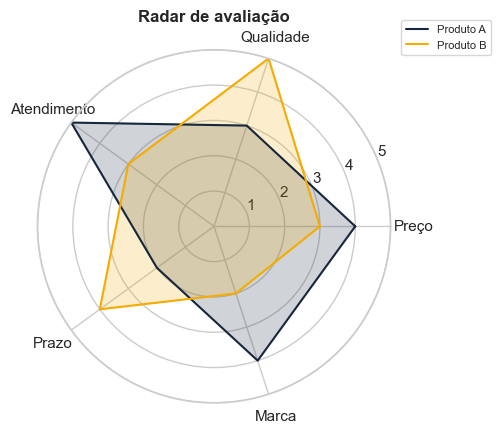

In [46]:
cats = ["Preço", "Qualidade", "Atendimento", "Prazo", "Marca"]
vals = {"Produto A": [4, 3, 5, 2, 4], "Produto B": [3, 5, 3, 4, 2]}
ang = np.linspace(0, 2 * np.pi, len(cats), endpoint=False)
ang = np.r_[ang, ang[0]]

fig = plt.figure(figsize=(5, 4.5))
ax = plt.subplot(polar=True)
for (nome, v), cor in zip(vals.items(), [NAVY, GOLD]):
    v = v + v[:1]
    ax.plot(ang, v, color=cor, label=nome)
    ax.fill(ang, v, color=cor, alpha=0.2)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(cats)
ax.set_ylim(0, 5)
ax.set_title("Radar de avaliação")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout(); plt.show()

### Coordenadas paralelas · *Parallel coordinates*

**Mensagem:** Cada linha é uma observação cruzando eixos verticais (variáveis): perfis, grupos e correlações.

**Quando usar:** Datasets com 4–10 variáveis numéricas e poucos grupos.

⚠️ **Cuidado:** Normalize as variáveis; muitas linhas viram uma massa ilegível.

*Biblioteca no exemplo: pandas/matplotlib*

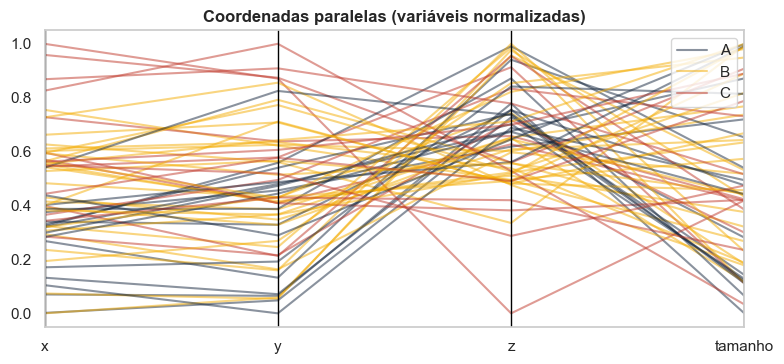

In [47]:
from pandas.plotting import parallel_coordinates

cols = ["x", "y", "z", "tamanho"]
amostra = df.sample(60, random_state=3).copy()
amostra[cols] = (amostra[cols] - amostra[cols].min()) / (amostra[cols].max() - amostra[cols].min())

fig, ax = plt.subplots(figsize=(8, 3.8))
parallel_coordinates(amostra[cols + ["grupo"]], "grupo", color=[NAVY, GOLD, RED], alpha=0.5, ax=ax)
ax.set(title="Coordenadas paralelas (variáveis normalizadas)")
plt.tight_layout(); plt.show()

### Bullet chart · *Bullet chart*

**Mensagem:** Compara um valor realizado com uma meta e faixas de desempenho (ruim/ok/bom).

**Quando usar:** Painéis de KPIs.

⚠️ **Cuidado:** Mantenha as faixas em tons suaves para o valor realizado se destacar.

*Biblioteca no exemplo: matplotlib*

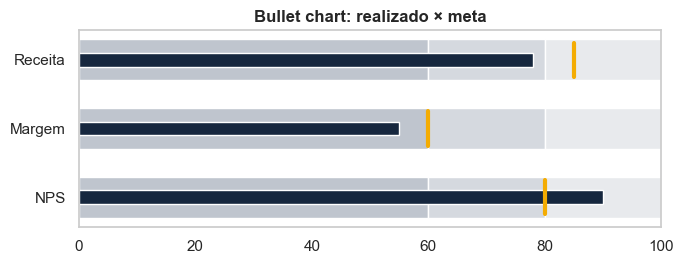

In [48]:
kpis = ["Receita", "Margem", "NPS"]
real = [78, 55, 90]
meta = [85, 60, 80]

fig, ax = plt.subplots(figsize=(7, 2.8))
for i, (r, m) in enumerate(zip(real, meta)):
    for ini, fim, cor in [(0, 60, "#BFC5CE"), (60, 80, "#D5D9DF"), (80, 100, "#E8EAED")]:
        ax.barh(i, fim - ini, left=ini, color=cor, height=0.6)
    ax.barh(i, r, color=NAVY, height=0.2)
    ax.plot([m, m], [i - 0.25, i + 0.25], color=GOLD, lw=3)
ax.set(yticks=range(3), yticklabels=kpis, xlim=(0, 100), title="Bullet chart: realizado × meta")
ax.invert_yaxis(); ax.grid(False)
plt.tight_layout(); plt.show()

### Símbolos agrupados · *Grouped symbol*

**Mensagem:** Pontos coloridos agrupados por subcategoria dentro de cada categoria: composição e magnitude juntas.

**Quando usar:** Contagens discretas divididas em subtipos.

⚠️ **Cuidado:** Use cada ponto para uma quantidade fixa e inclua legenda.

*Biblioteca no exemplo: matplotlib*

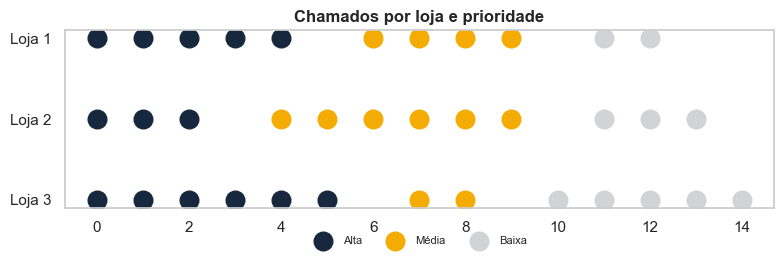

In [49]:
dados = pd.DataFrame({"Alta": [5, 3, 6], "Média": [4, 6, 2], "Baixa": [2, 3, 5]},
                     index=["Loja 1", "Loja 2", "Loja 3"])
cores = {"Alta": NAVY, "Média": GOLD, "Baixa": GRAY}

fig, ax = plt.subplots(figsize=(8, 2.8))
for i, loja in enumerate(dados.index):
    cursor = 0
    for faixa, cor in cores.items():
        k = dados.loc[loja, faixa]
        ax.scatter(cursor + np.arange(k), [i] * k, s=180, color=cor, label=faixa if i == 0 else None)
        cursor += k + 1
ax.set(yticks=range(3), yticklabels=dados.index, title="Chamados por loja e prioridade")
ax.invert_yaxis(); ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False); ax.grid(False)
plt.tight_layout(); plt.show()

## Partes de um todo · *Part-to-whole*

**Pergunta:** Como o total se divide?

Mostra como uma entidade única se decompõe em seus componentes. Se o interesse do leitor estiver apenas no tamanho dos componentes, considere um gráfico de magnitude.

### Colunas/barras empilhadas · *Stacked column/bar*

**Mensagem:** Mostra o total e a composição de cada categoria ou período.

**Quando usar:** Composição ao longo do tempo ou entre categorias; até ~5 componentes.

⚠️ **Cuidado:** Apenas o primeiro segmento tem base comum; os demais são difíceis de comparar.

*Biblioteca no exemplo: pandas/matplotlib*

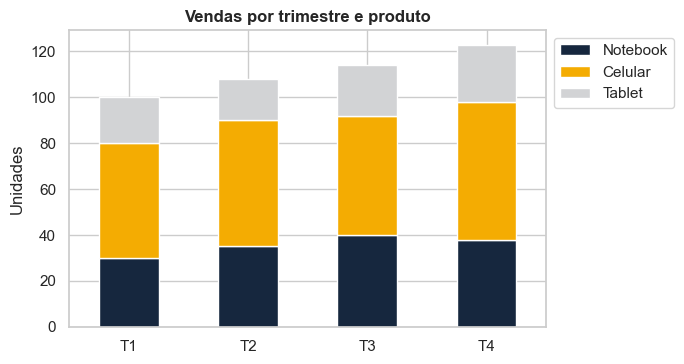

In [50]:
trim = pd.DataFrame({"Notebook": [30, 35, 40, 38], "Celular": [50, 55, 52, 60], "Tablet": [20, 18, 22, 25]},
                    index=["T1", "T2", "T3", "T4"])

ax = trim.plot(kind="bar", stacked=True, color=[NAVY, GOLD, GRAY], figsize=(7, 3.8), rot=0)
ax.set(title="Vendas por trimestre e produto", ylabel="Unidades")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

### Marimekko (Mekko) · *Marimekko*

**Mensagem:** Variante de colunas empilhadas com larguras variáveis. Veja o snippet em Magnitude.

### Gráfico de pizza · *Pie chart*

**Mensagem:** Partes de um todo com poucas fatias. Veja o snippet no início do notebook.

### Donut · *Donut chart*

**Mensagem:** Pizza com furo central: mesma mensagem de partes de um todo, com espaço para destacar o total.

**Quando usar:** Poucas partes; KPI central.

⚠️ **Cuidado:** Mesmas ressalvas da pizza sobre percepção de ângulos.

*Biblioteca no exemplo: matplotlib*

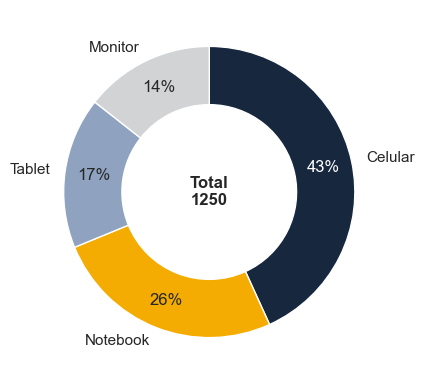

In [51]:
partes = vendas_prod.sort_values(ascending=False).head(4)

fig, ax = plt.subplots(figsize=(5, 4))
_, _, pct = ax.pie(partes, labels=partes.index, autopct="%1.0f%%", startangle=90, counterclock=False,
                   pctdistance=0.8, colors=[NAVY, GOLD, "#8FA3C0", GRAY],
                   wedgeprops=dict(width=0.4, edgecolor="white"))
pct[0].set_color("white")
ax.text(0, 0, f"Total\n{partes.sum()}", ha="center", va="center", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

### Diagrama de Voronoi · *Voronoi*

**Mensagem:** Divide o plano em células por proximidade a pontos: mostra área de influência/ pertencimento.

**Quando usar:** Cobertura de lojas, zonas de influência, partição proporcional.

⚠️ **Cuidado:** As áreas dependem da posição dos pontos; só é partes-do-todo se a área for calibrada.

*Biblioteca no exemplo: matplotlib + scipy*

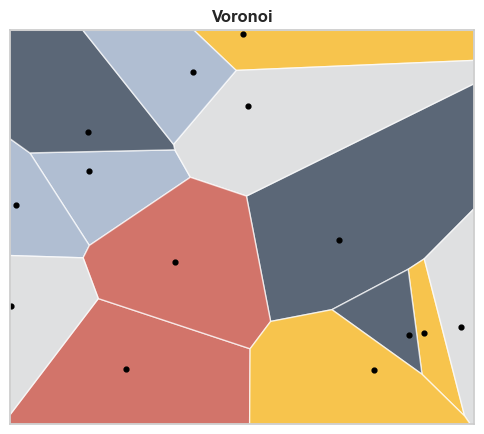

In [53]:
from scipy.spatial import Voronoi

pts = rng.uniform(0, 10, (14, 2))
# pontos refletidos nas bordas fecham as células de borda
vor = Voronoi(np.vstack([pts,
                         pts * [-1, 1], pts * [1, -1], pts * [-1, -1] + [0, 0],
                         pts * [-1, 1] + [20, 0], pts * [1, -1] + [0, 20]]))

fig, ax = plt.subplots(figsize=(5, 4.5))
cores = sns.color_palette([NAVY, GOLD, "#8FA3C0", GRAY, RED], len(pts))
for i in range(len(pts)):
    reg = vor.regions[vor.point_region[i]]
    if -1 not in reg and len(reg) > 0:
        poly = vor.vertices[reg]
        ax.fill(*zip(*poly), color=cores[i], alpha=0.7, edgecolor="white")
ax.scatter(*pts.T, color="black", s=12)
ax.set(xlim=(0, 10), ylim=(0, 10), title="Voronoi", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

### Gráfico de arco (parlamento) · *Arc chart*

**Mensagem:** Meia-rosca que mostra a composição de um todo em formato de arco (ex.: cadeiras num parlamento).

**Quando usar:** Resultados eleitorais, composição de um órgão.

⚠️ **Cuidado:** Fica ilegível com muitas fatias pequenas.

*Biblioteca no exemplo: matplotlib*

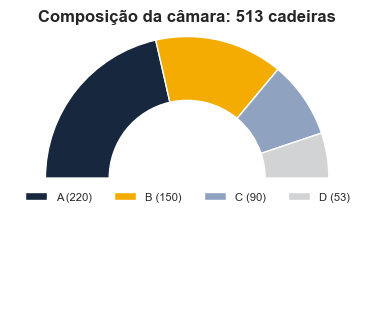

In [54]:
partidos = ["A", "B", "C", "D"]
cadeiras = [220, 150, 90, 53]
cores = [NAVY, GOLD, "#8FA3C0", GRAY]

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.pie(cadeiras + [sum(cadeiras)], colors=cores + ["none"], startangle=180, counterclock=False,
       wedgeprops=dict(width=0.45, edgecolor="white"))
ax.set_ylim(-0.05, 1.05)
for p, c, cor in zip(partidos, cadeiras, cores):
    ax.bar(0, 0, color=cor, label=f"{p} ({c})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=8, frameon=False)
ax.set_title("Composição da câmara: 513 cadeiras")
plt.tight_layout(); plt.show()

### Grid plot (waffle) · *Gridplot*

**Mensagem:** Grade 10×10: cada quadradinho = 1%. Intuitivo para comunicar proporções.

**Quando usar:** Uma ou poucas proporções para público geral.

⚠️ **Cuidado:** Arredonde com cuidado para somar 100.

*Biblioteca no exemplo: matplotlib*

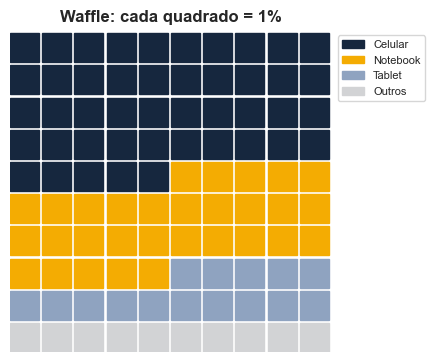

In [55]:
parte = {"Celular": 45, "Notebook": 30, "Tablet": 15, "Outros": 10}
cores = [NAVY, GOLD, "#8FA3C0", GRAY]

cel = [c for c, (nome, v) in zip(cores, parte.items()) for _ in range(v)]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
for k, cor in enumerate(cel):
    ax.add_patch(plt.Rectangle((k % 10, 9 - k // 10), 0.9, 0.9, color=cor))
ax.set(xlim=(0, 10), ylim=(0, 10), title="Waffle: cada quadrado = 1%")
ax.set_aspect("equal"); ax.axis("off")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in cores], list(parte), loc="upper left",
          bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); plt.show()

### Diagrama de Venn · *Venn diagram*

**Mensagem:** Mostra a interseção entre conjuntos: o que é exclusivo e o que é compartilhado.

**Quando usar:** Públicos que se sobrepõem (clientes que compram A, B ou ambos).

⚠️ **Cuidado:** Áreas não são proporcionais aos tamanhos reais, a menos que sejam calculadas.

*Biblioteca no exemplo: matplotlib*

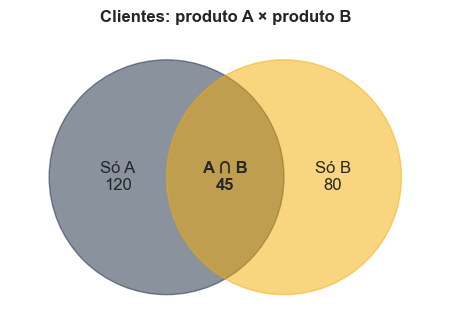

In [56]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.add_patch(Circle((-0.6, 0), 1.2, color=NAVY, alpha=0.5))
ax.add_patch(Circle((0.6, 0), 1.2, color=GOLD, alpha=0.5))
ax.text(-1.1, 0, "Só A\n120", ha="center", va="center")
ax.text(0, 0, "A ∩ B\n45", ha="center", va="center", fontweight="bold")
ax.text(1.1, 0, "Só B\n80", ha="center", va="center")
ax.set(xlim=(-2.2, 2.2), ylim=(-1.5, 1.5), title="Clientes: produto A × produto B")
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

### Cascata (waterfall) · *Waterfall chart*

**Mensagem:** Mostra como um valor inicial se transforma em um final por meio de acréscimos e reduções sucessivas.

**Quando usar:** Ponte de lucro, variação de caixa, composição de resultado.

⚠️ **Cuidado:** A ordem das etapas altera a leitura; sinalize totais (início/fim).

*Biblioteca no exemplo: matplotlib*

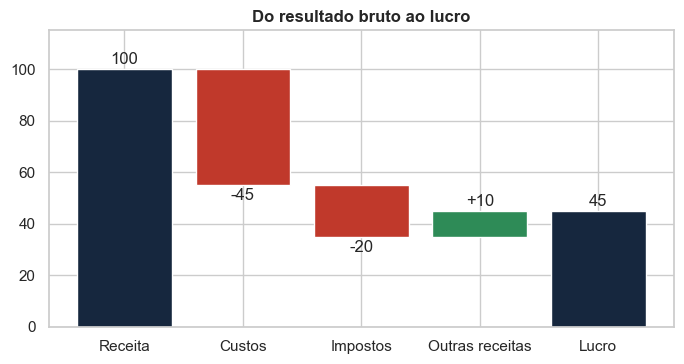

In [57]:
etapas = ["Receita", "Custos", "Impostos", "Outras receitas", "Lucro"]
valores = [100, -45, -20, 10, None]
acum = np.cumsum([v for v in valores if v is not None])
final = acum[-1]

fig, ax = plt.subplots()
base = 0
for i, v in enumerate(valores):
    if v is None:
        ax.bar(i, final, color=NAVY)
        ax.text(i, final + 2, f"{final}", ha="center")
        break
    cor = NAVY if i == 0 else (RED if v < 0 else "#2E8B57")
    ax.bar(i, v, bottom=base if i else 0, color=cor)
    ax.text(i, (base if i else 0) + v + (2 if v > 0 else -6), f"{v:+d}" if i else str(v), ha="center")
    base = acum[i]
ax.set(xticks=range(len(etapas)), xticklabels=etapas, title="Do resultado bruto ao lucro", ylim=(0, 115))
plt.tight_layout(); plt.show()

## Espacial · *Spatial*

**Pergunta:** Onde isso acontece?

Além de mapas de localização, quando padrões espaciais importam mais que qualquer outra coisa, use um mapa com a codificação apropriada. Os exemplos abaixo são esquemáticos (sem arquivos de mapa); em projetos reais use geopandas, plotly ou folium.

### Coroplético (esquemático) · *Basic choropleth*

**Mensagem:** Colore regiões geográficas conforme um valor (taxa, índice).

**Quando usar:** Taxas e indicadores normalizados por região (nunca totais brutos).

⚠️ **Cuidado:** Regiões grandes dominam visualmente. Para mapas reais use `geopandas` e arquivos shapefile/GeoJSON.

*Biblioteca no exemplo: matplotlib*

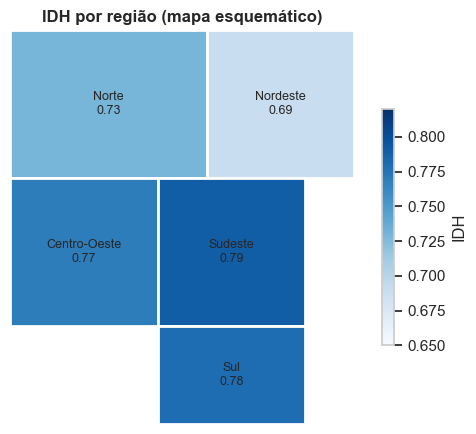

In [58]:
from matplotlib.patches import Rectangle
from matplotlib import cm, colors

reg = {"Norte": (0, 3, 4, 3, 0.73), "Nordeste": (4, 3, 3, 3, 0.69), "Centro-Oeste": (0, 0, 3, 3, 0.77),
       "Sudeste": (3, 0, 3, 3, 0.79), "Sul": (3, -2, 3, 2, 0.78)}
norm = colors.Normalize(0.65, 0.82)

fig, ax = plt.subplots(figsize=(6, 4.5))
for nome, (x, y, w, h, v) in reg.items():
    ax.add_patch(Rectangle((x, y), w, h, facecolor=cm.Blues(norm(v)), edgecolor="white", lw=2))
    ax.text(x + w / 2, y + h / 2, f"{nome}\n{v:.2f}", ha="center", va="center", fontsize=9)
ax.set(xlim=(0, 7), ylim=(-2, 6), title="IDH por região (mapa esquemático)")
ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap="Blues"), ax=ax, shrink=0.6, label="IDH")
plt.tight_layout(); plt.show()

### Mapa de fluxo · *Flow map*

**Mensagem:** Mostra movimentos entre lugares com setas cuja espessura é proporcional ao volume.

**Quando usar:** Migração, comércio, rotas aéreas.

⚠️ **Cuidado:** Muitas setas viram bagunça; agregue ou filtre os fluxos principais.

*Biblioteca no exemplo: matplotlib*

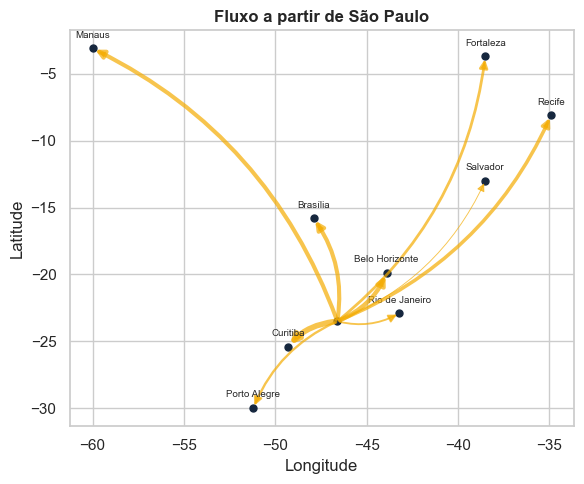

In [59]:
origem = cidades.iloc[0]  # São Paulo
destinos = cidades.iloc[1:]
fluxo = rng.integers(10, 100, len(destinos))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cidades["lon"], cidades["lat"], color=NAVY, s=25, zorder=3)
for (_, d), f in zip(destinos.iterrows(), fluxo):
    ax.annotate("", xy=(d["lon"], d["lat"]), xytext=(origem["lon"], origem["lat"]),
                arrowprops=dict(arrowstyle="-|>", lw=f / 20, color=GOLD, alpha=0.7,
                                connectionstyle="arc3,rad=0.2"))
    ax.text(d["lon"], d["lat"] + 0.8, d["nome"], fontsize=7, ha="center")
ax.set(title="Fluxo a partir de São Paulo", xlabel="Longitude", ylabel="Latitude")
plt.tight_layout(); plt.show()

### Mapa de contorno · *Contour map*

**Mensagem:** Linhas ou faixas que ligam pontos de mesmo valor (altitude, temperatura, densidade).

**Quando usar:** Superfícies contínuas: relevo, pressão, probabilidade.

⚠️ **Cuidado:** Escolha poucos níveis e uma paleta sequencial/divergente adequada.

*Biblioteca no exemplo: matplotlib*

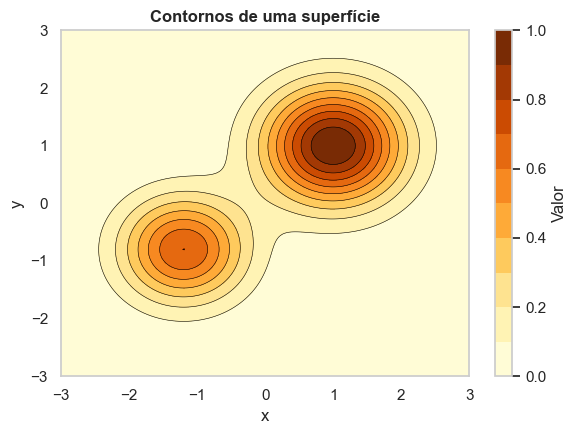

In [60]:
x, y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
z = np.exp(-((x - 1) ** 2 + (y - 1) ** 2)) + 0.7 * np.exp(-((x + 1.2) ** 2 + (y + 0.8) ** 2) / 0.8)

fig, ax = plt.subplots(figsize=(6, 4.5))
cf = ax.contourf(x, y, z, levels=10, cmap="YlOrBr")
ax.contour(x, y, z, levels=10, colors="black", linewidths=0.4)
fig.colorbar(cf, label="Valor")
ax.set(title="Contornos de uma superfície", xlabel="x", ylabel="y")
plt.tight_layout(); plt.show()

### Cartograma equalizado (tile map) · *Equalised cartogram*

**Mensagem:** Cada região ocupa a mesma área, para que valores sejam comparáveis sem o viés do tamanho territorial.

**Quando usar:** Comparar regiões de tamanhos muito desiguais (estados, países).

⚠️ **Cuidado:** A forma geográfica é sacrificada: mantenha a vizinhança aproximada.

*Biblioteca no exemplo: matplotlib*

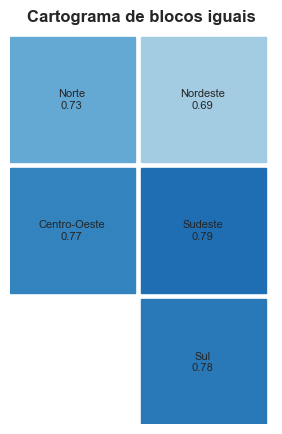

In [61]:
tiles = {"Norte": (0, 2, 0.73), "Nordeste": (1, 2, 0.69), "Centro-Oeste": (0, 1, 0.77),
         "Sudeste": (1, 1, 0.79), "Sul": (1, 0, 0.78)}

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for nome, (cx, cy, v) in tiles.items():
    ax.add_patch(plt.Rectangle((cx, cy), 0.95, 0.95, color=plt.cm.Blues((v - 0.6) / 0.25)))
    ax.text(cx + 0.47, cy + 0.47, f"{nome}\n{v:.2f}", ha="center", va="center", fontsize=8)
ax.set(xlim=(0, 2), ylim=(0, 3), title="Cartograma de blocos iguais")
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

### Cartograma escalado · *Scaled cartogram*

**Mensagem:** Distorce o tamanho de cada região em proporção ao valor (população, PIB).

**Quando usar:** Mostrar "peso" de cada região na variável medida.

⚠️ **Cuidado:** A distorção pode dificultar o reconhecimento da forma geográfica.

*Biblioteca no exemplo: matplotlib*

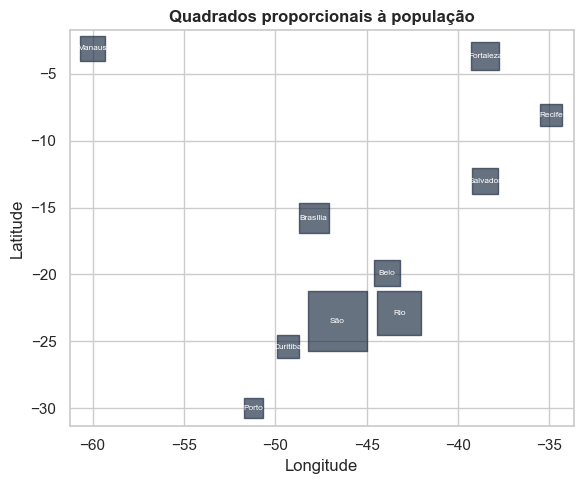

In [62]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cidades["lon"], cidades["lat"], s=cidades["pop"] * 150, marker="s", color=NAVY, alpha=0.65)
for _, r in cidades.iterrows():
    ax.text(r["lon"], r["lat"], r["nome"].split()[0], ha="center", va="center", fontsize=6, color="white")
ax.set(title="Quadrados proporcionais à população", xlabel="Longitude", ylabel="Latitude")
plt.tight_layout(); plt.show()

### Mapa de densidade de pontos · *Dot density*

**Mensagem:** Cada ponto representa N unidades: mostra concentração e dispersão espacial.

**Quando usar:** População, ocorrências, estabelecimentos.

⚠️ **Cuidado:** O espalhamento aleatório dentro da região é uma aproximação.

*Biblioteca no exemplo: matplotlib*

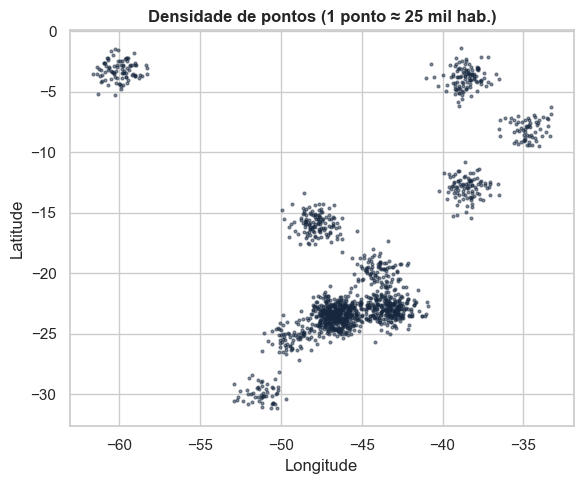

In [63]:
pts = []
for _, r in cidades.iterrows():
    k = int(r["pop"] * 40)
    pts.append(np.c_[rng.normal(r["lon"], 0.8, k), rng.normal(r["lat"], 0.8, k)])
pts = np.vstack(pts)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pts[:, 0], pts[:, 1], s=4, color=NAVY, alpha=0.5)
ax.set(title="Densidade de pontos (1 ponto ≈ 25 mil hab.)", xlabel="Longitude", ylabel="Latitude")
plt.tight_layout(); plt.show()

### Mapa de calor espacial · *Heat map (spatial)*

**Mensagem:** Estima a densidade contínua de pontos no espaço, destacando zonas quentes.

**Quando usar:** Ocorrências geográficas, tráfego, vendas por local.

⚠️ **Cuidado:** O raio de suavização (bandwidth) altera as zonas: informe-o.

*Biblioteca no exemplo: seaborn*

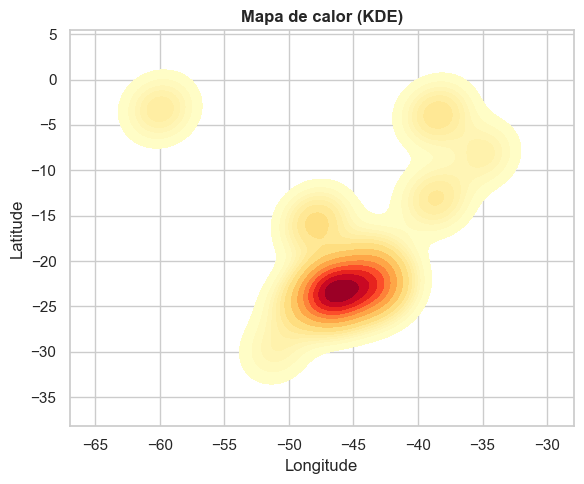

In [64]:
pts = []
for _, r in cidades.iterrows():
    k = int(r["pop"] * 40)
    pts.append(np.c_[rng.normal(r["lon"], 0.8, k), rng.normal(r["lat"], 0.8, k)])
pts = np.vstack(pts)

fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(x=pts[:, 0], y=pts[:, 1], fill=True, cmap="YlOrRd", levels=15, thresh=0.05, ax=ax)
ax.set(title="Mapa de calor (KDE)", xlabel="Longitude", ylabel="Latitude")
plt.tight_layout(); plt.show()

## Fluxo · *Flow*

**Pergunta:** De onde para onde as coisas se movem?

Mostra volumes ou intensidade de movimento entre dois ou mais estados ou condições. Podem ser sequências lógicas ou localizações geográficas.

### Diagrama de Sankey · *Sankey diagram*

**Mensagem:** Fluxos entre etapas com larguras proporcionais ao volume: de onde vem e para onde vai.

**Quando usar:** Fluxo de energia, orçamento, funil, migração entre categorias.

⚠️ **Cuidado:** Muitos nós geram confusão; para fluxos complexos considere `plotly` ou `pySankey`.

*Biblioteca no exemplo: matplotlib*

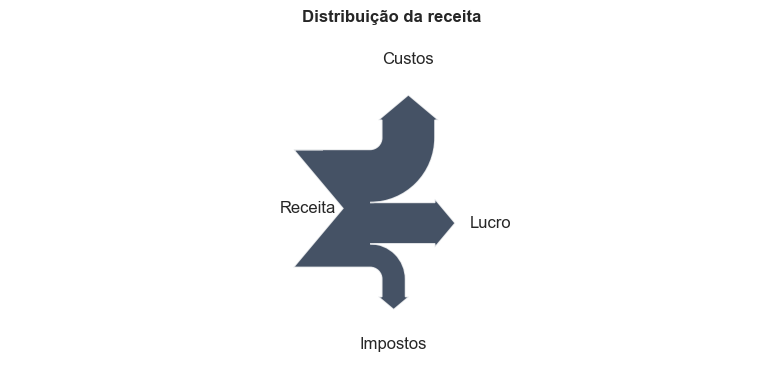

In [65]:
from matplotlib.sankey import Sankey

fig, ax = plt.subplots(figsize=(8, 4))
Sankey(ax=ax, unit=None, scale=0.01, offset=0.3).add(
    flows=[100, -45, -20, -35],
    labels=["Receita", "Custos", "Impostos", "Lucro"],
    orientations=[0, 1, -1, 0],
    facecolor=NAVY, alpha=0.8).finish()
ax.set_title("Distribuição da receita")
ax.axis("off")
plt.tight_layout(); plt.show()

### Cascata (waterfall) · *Waterfall chart*

**Mensagem:** Fluxo sequencial de acréscimos e reduções até o resultado final. Veja o snippet em Partes de um todo.

### Diagrama de cordas (chord) · *Chord diagram*

**Mensagem:** Relações e fluxos entre entidades dispostas em círculo; cordas ligam pares com largura proporcional.

**Quando usar:** Matrizes de origem-destino (comércio entre países, migração).

⚠️ **Cuidado:** Densos demais com muitas entidades; use cores e transparência.

*Biblioteca no exemplo: matplotlib*

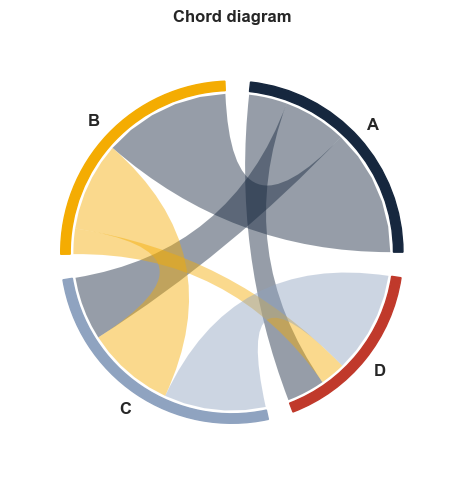

In [66]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Wedge

nomes = ["A", "B", "C", "D"]
M = np.array([[0, 10, 5, 3], [10, 0, 7, 2], [5, 7, 0, 8], [3, 2, 8, 0]])
cores = [NAVY, GOLD, "#8FA3C0", RED]
tot = M.sum(1); gap = 0.15
esc = (2 * np.pi - gap * len(nomes)) / tot.sum()
inicio = np.r_[0, np.cumsum(tot * esc + gap)[:-1]]
P = lambda a, r=1: (r * np.cos(a), r * np.sin(a))

fig, ax = plt.subplots(figsize=(5, 5))
pos = inicio.copy()
for i in range(len(nomes)):
    ax.add_patch(Wedge((0, 0), 1.08, np.degrees(inicio[i]), np.degrees(inicio[i] + tot[i] * esc),
                       width=0.06, color=cores[i]))
    am = inicio[i] + tot[i] * esc / 2
    ax.text(*P(am, 1.2), nomes[i], ha="center", va="center", fontweight="bold")
for i in range(len(nomes)):
    for j in range(i + 1, len(nomes)):
        w = M[i, j] * esc
        a0, b0 = pos[i], pos[j]
        pos[i] += w; pos[j] += w
        arco_a = [P(a) for a in np.linspace(a0, a0 + w, 6)]
        arco_b = [P(a) for a in np.linspace(b0, b0 + w, 6)]
        verts = [arco_a[0]] + arco_a[1:] + [(0, 0), arco_b[0]] + arco_b[1:] + [(0, 0), arco_a[0]]
        codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CURVE3] * 2 + [Path.LINETO] * 5 + [Path.CURVE3] * 2
        ax.add_patch(PathPatch(Path(verts, codes), facecolor=cores[i], alpha=0.45, edgecolor="none"))
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), title="Chord diagram")
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

### Rede (network) · *Network diagram*

**Mensagem:** Nós conectados por arestas: estrutura de relações, centralidade e comunidades.

**Quando usar:** Redes sociais, dependências, cadeias de fornecimento.

⚠️ **Cuidado:** Com muitos nós o gráfico vira um "novelo"; filtre ou agrupe. Para layouts avançados use `networkx`.

*Biblioteca no exemplo: matplotlib*

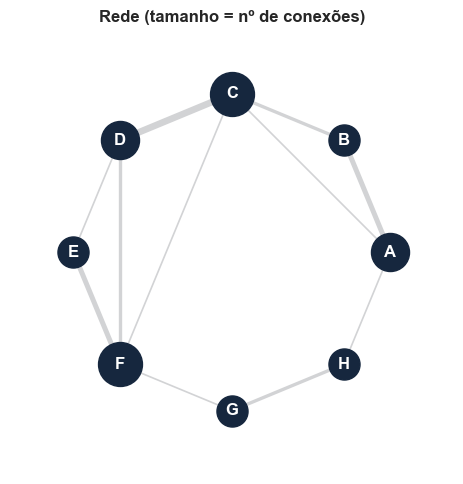

In [67]:
nos = ["A", "B", "C", "D", "E", "F", "G", "H"]
arestas = [("A", "B", 3), ("A", "C", 1), ("B", "C", 2), ("C", "D", 4), ("D", "E", 1),
           ("D", "F", 2), ("E", "F", 3), ("F", "G", 1), ("G", "H", 2), ("A", "H", 1), ("C", "F", 1)]
ang = np.linspace(0, 2 * np.pi, len(nos), endpoint=False)
xy = {n: (np.cos(a), np.sin(a)) for n, a in zip(nos, ang)}
grau = {n: sum(n in (a, b) for a, b, _ in arestas) for n in nos}

fig, ax = plt.subplots(figsize=(5, 5))
for a, b, w in arestas:
    ax.plot(*zip(xy[a], xy[b]), color=GRAY, lw=w * 1.2, zorder=1)
for n in nos:
    ax.scatter(*xy[n], s=grau[n] * 250, color=NAVY, zorder=2)
    ax.text(*xy[n], n, color="white", ha="center", va="center", fontweight="bold")
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), title="Rede (tamanho = nº de conexões)")
ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

# Guia rápido de escolha

| Quero mostrar... | Categoria | Boas primeiras opções |
|---|---|---|
| Quem está acima/abaixo da meta | Deviation | barras divergentes, surplus/deficit |
| Relação entre variáveis | Correlation | scatter, bolhas, heatmap XY |
| Ordem / posição | Ranking | barras ordenadas, lollipop, slope, bump |
| Forma dos dados | Distribution | histograma, boxplot, violin, ECDF |
| Evolução | Change over Time | linhas, colunas, área, candlestick, fan |
| Tamanhos | Magnitude | barras/colunas, pareadas, bullet |
| Composição | Part-to-whole | empilhadas, treemap, waterfall, (pizza com moderação) |
| Localização | Spatial | coroplético, símbolos proporcionais, heat map |
| Movimento | Flow | Sankey, chord, rede |

# Exercícios

**Exercício 1 — Ranking.** Faça um gráfico de barras horizontais ordenadas com `vendas_prod`, destacando em dourado apenas o **menor** valor e adicionando o valor ao fim de cada barra.

In [68]:
# TODO


**Exercício 2 — Distribuição.** Compare a distribuição de `df['y']` entre os grupos A, B e C. Escolha **um** gráfico (boxplot, violin ou ECDF) e explique em um comentário por que ele comunica melhor a mensagem.

In [69]:
# TODO


**Exercício 3 — Desvio.** Usando `var_pct`, faça barras divergentes mas agora com azul para valores positivos acima de 5, cinza entre 0 e 5 e vermelho para negativos.

In [70]:
# TODO


**Exercício 4 — Evolução e correlação.** Com `serie`, faça um gráfico de colunas (receita) + linha (custo) com dois eixos. Depois faça uma dispersão conectada de custo × receita. A mensagem muda? Comente.

In [71]:
# TODO


**Desafio final.** Escolha um dataset seu (ou `sns.load_dataset("tips")`), defina **uma mensagem** (ex.: "quem gasta mais?") e escolha um gráfico do Visual Vocabulary que a comunique. Justifique em 2 linhas.

In [72]:
# TODO
